## Exploratory Data Analysis for Reading the Reader project

Based on theory research, the following features are indicative of cognitive load.
A positive relation is expected for:
* saccade length
* saccade velocity
* pupil dilation now RIPA 2
* fixation duration
* frequency of regression

A negative relation is expected for:
* fixations rate -- number of fixations/time interval (2s)
* blink rate
* skipping rate

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rdata
import json

import re

##### Parse text

In [6]:
file_path = "../data/raw/experiment-processed-keerthi.json"
file = json.load(open(file_path))


In [ ]:

def parse_text(self, session_id, materials):
        sentence_to_words_index = {}
        
        for material in materials:

            raw_blocks = re.split(r'\n{2,}', material["markdown"].strip())

            material_id = material["id"]

            for block_index, block_text in enumerate(raw_blocks):
                block_text = block_text.strip()
            
                if block_text.startswith('#'):
                    sentences = block_text
                else:
                    sentences = re.split(r'(?<=[.!?])\s+', block_text)

                for sentence_index, sentence_text in enumerate(sentences):
                    sentence_text = sentence_text.strip()

                    sentence_id = f"{session_id}:{material_id}:{block_index}:{sentence_index}:sentence:{sentence_index}"
                    print(sentence_id)

                    sentence_text = re.sub(r'^#+\s*', '', sentence_text)
                    tokens = sentence_text.split()
                    words = []
                    for token in tokens:
                        word = re.sub(r'^[^\w]+|[^\w]+$', '', token)
                        if word:
                            words.append(word)

                    word_ids = []

                    for word_index, word in enumerate(words):
                        word_id = f"{session_id}:{material_id}:{block_index}:sentence:{sentence_index}:word:{word_index}"
                        word_ids.append(word_id)

                    sentence_to_words_index[sentence_id] = word_ids
                    print(sentence_to_words_index[sentence_id])

        return sentence_to_words_index

In [ ]:
parse_text(file["experiment"]["run"]["sourceExperimentSetupId"], )

In [ ]:
sentence_to_words_index = {}

In [8]:
for material in file["experiment"]["run"]["materials"]:
    raw_blocks = re.split(r'\n{2,}', material["markdown"].strip())
    print(raw_blocks)

['# Lady and the Tramp', "Lady and the Tramp is a 1955 American animated musical romantic comedy film produced by Walt Disney Productions and released by Buena Vista Film Distribution. Based on Ward Greene's 1945 Cosmopolitan magazine story Happy Dan, the Cynical Dog, it was directed by Hamilton Luske, Clyde Geronimi, and Wilfred Jackson. The film features the voices of Peggy Lee, Barbara Luddy, Larry Roberts, Bill Thompson, Bill Baucom, Stan Freberg, Verna Felton, Alan Reed, George Givot, Dallas McKennon, and Lee Millar. The film follows Lady, the pampered cocker spaniel, as she grows from puppy to adult, deals with changes in her family, and meets and falls in love with the homeless mutt Tramp.", "The inspiration for Lady and the Tramp originated in 1925 when Walt Disney presented his wife Lillian with a chow puppy in a hatbox. In 1937, Joe Grant, a storyboard artist, pitched to Disney an original idea as inspired by his English Springer Spaniel. Throughout the 1940s, the project und

##### MECO

In [4]:
MECO_data = rdata.read_rda("../data/raw/joint_data_l2_trimmed_version2.0.rda")["joint.data"]

In [5]:
MECO_data = MECO_data[MECO_data["lang"] != "en"]
MECO_data = MECO_data[MECO_data["dur"] > 80 | MECO_data["dur"].isna()]

In [6]:
MECO_data.columns

Index(['subid', 'trialid', 'trialnum', 'itemid', 'cond', 'sentnum', 'wordnum',
       'word', 'blink', 'skip', 'nrun', 'reread', 'nfix', 'refix', 'reg.in',
       'reg.out', 'dur', 'firstrun.skip', 'firstrun.nfix', 'firstrun.refix',
       'firstrun.reg.in', 'firstrun.reg.out', 'firstrun.dur',
       'firstrun.gopast', 'firstrun.gopast.sel', 'firstfix.sac.in',
       'firstfix.sac.out', 'firstfix.launch', 'firstfix.land',
       'firstfix.cland', 'firstfix.dur', 'singlefix', 'singlefix.sac.in',
       'singlefix.sac.out', 'singlefix.launch', 'singlefix.land',
       'singlefix.cland', 'singlefix.dur', 'lang', 'trial', 'uniform_id'],
      dtype='object')

In [ ]:
features = MECO_data[["firstfix.dur", "nfix"]]
MECO_data["cumulative_reg_out"] = MECO_data.groupby(["subid", "trialid"])["reg.out"].cumsum()
MECO_data["cumulative_movements"] = MECO_data.groupby(["subid", "trialid"]).cumcount() + 1
features["reg_frequency"] = MECO_data["cumulative_reg_out"] / MECO_data["cumulative_movements"]

features["firstfix.dur"] = np.log1p(features["firstfix.dur"])
features["nfix"] = np.log1p(features["nfix"])

X = features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train K Means model
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

features["cluster"] = kmeans.labels_
print(features.groupby("cluster").mean())

         firstfix.dur      nfix  reg_frequency
cluster                                       
0            5.198411  1.308934       0.312244
1            5.402267  0.780533       0.180649


/var/folders/y2/4wrcf4_j2yggtw4qrwqkl7b00000gn/T/ipykernel_82486/3120043343.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["reg_frequency"] = MECO_data["cumulative_reg_out"] / MECO_data["cumulative_movements"]
/var/folders/y2/4wrcf4_j2yggtw4qrwqkl7b00000gn/T/ipykernel_82486/3120043343.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["firstfix.dur"] = np.log1p(features["firstfix.dur"])
/var/folders/y2/4wrcf4_j2yggtw4qrwqkl7b00000gn/T/ipykernel_82486/3120043343.py:7: SettingWithCopyW

In [ ]:
from sklearn.metrics import silhouette_score
score_normal = silhouette_score(X_scaled, kmeans.labels_)

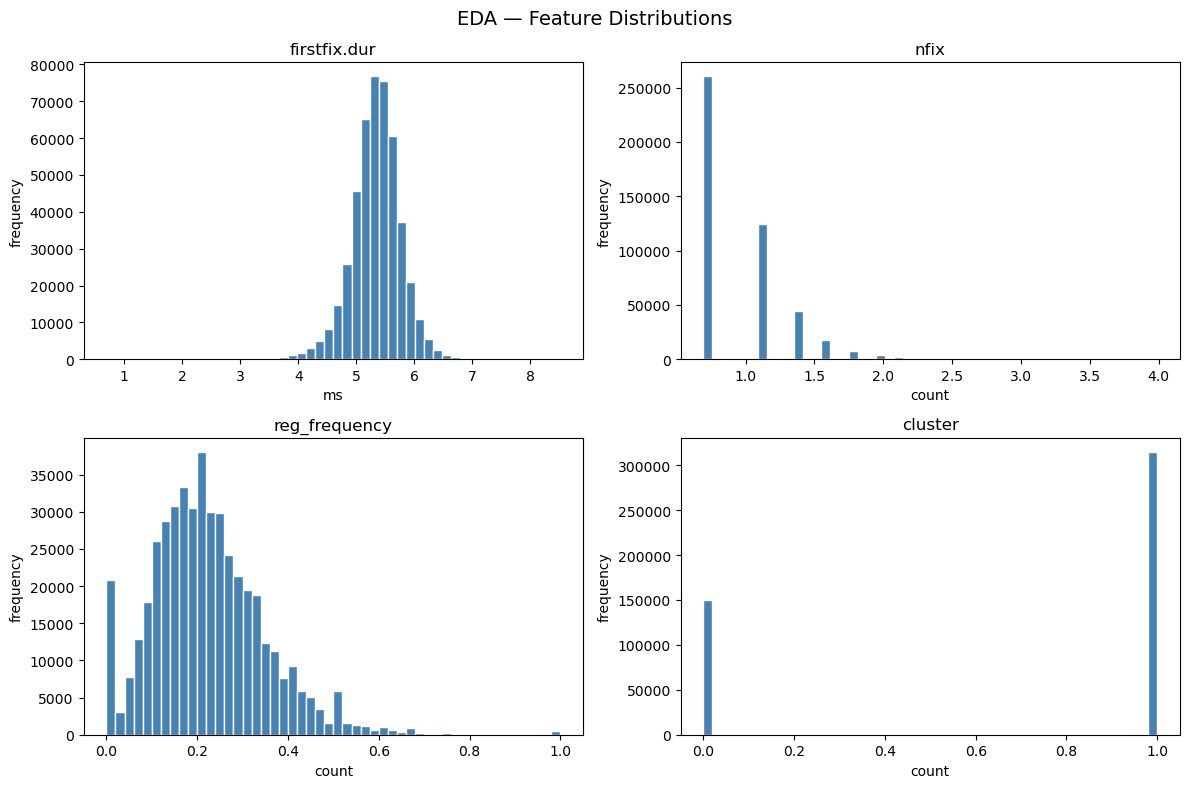

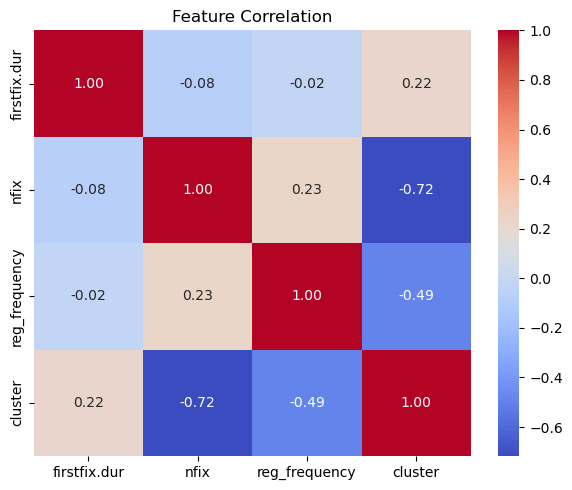

In [39]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("EDA — Feature Distributions", fontsize=14)

for ax, col in zip(axes.flat, features.columns):
    ax.hist(features[col], bins=50, edgecolor="white", color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("ms" if "dur" in col else "count")
    ax.set_ylabel("frequency")

plt.tight_layout()
plt.show()

# correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(features.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature Correlation")
plt.tight_layout()
plt.show()

In [33]:
crit = MECO_data.groupby("uniform_id")["dur"].quantile(0.99, interpolation="linear").reset_index()
crit = crit.rename(columns={"dur": "dur.crit"})
crit = crit.reset_index(drop=True)

In [32]:
MECO_data.iloc[0:10]

,subid,trialid,trialnum,itemid,cond,sentnum,wordnum,word,blink,skip,...,singlefix,singlefix.sac.in,singlefix.sac.out,singlefix.launch,singlefix.land,singlefix.cland,singlefix.dur,lang,trial,uniform_id
1,DU_04,1,1.0,1,1.0,1.0,1.0,Samuel,0.0,0.0,...,1.0,<NA>,16,NaN,1.0,-2.5,48.0,du,<NA>,du_4
2,DU_04,1,1.0,1,1.0,4.0,109.0,days,0.0,0.0,...,1.0,-8,7,-5.0,3.0,0.5,344.0,du,<NA>,du_4
4,DU_04,1,1.0,1,1.0,4.0,111.0,reach,0.0,0.0,...,1.0,-91,-8,-86.0,3.0,0.0,124.0,du,<NA>,du_4
6,DU_04,1,1.0,1,1.0,4.0,113.0,because,0.0,0.0,...,1.0,8,17,8.0,0.0,-4.0,251.0,du,<NA>,du_4
7,DU_04,1,1.0,1,1.0,4.0,114.0,of,0.0,0.0,...,1.0,-4,8,-1.0,2.0,0.5,180.0,du,<NA>,du_4
8,DU_04,1,1.0,1,1.0,4.0,115.0,the,0.0,0.0,...,1.0,-3,-4,-1.0,3.0,1.0,119.0,du,<NA>,du_4
9,DU_04,1,1.0,1,1.0,4.0,116.0,distance.,0.0,0.0,...,1.0,17,-3,15.0,2.0,-3.0,158.0,du,<NA>,du_4
10,DU_04,1,1.0,1,1.0,5.0,117.0,Morse,0.0,0.0,...,0.0,<NA>,<NA>,NaN,NaN,NaN,NaN,du,<NA>,du_4
11,DU_04,1,1.0,1,1.0,5.0,118.0,rushed,0.0,0.0,...,0.0,<NA>,<NA>,NaN,NaN,NaN,NaN,du,<NA>,du_4
13,DU_04,1,1.0,1,1.0,5.0,120.0,his,0.0,0.0,...,1.0,9,7,7.0,2.0,0.0,325.0,du,<NA>,du_4


In [51]:
MECO_data_readerate = rdata.read_rda("../data/raw/joint.l2.readrate_version2.0.rda")["u"]

In [52]:
MECO_data_readerate

,uniform_id,lang,trialid,rate
40,du_4,du,12,227.0
41,du_4,du,2,389.0
42,du_4,du,11,209.0
43,du_4,du,1,306.0
46,du_4,du,10,248.0
...,...,...,...,...
9599,tr_52,tr,9,206.0
9601,tr_52,tr,1,190.0
9602,tr_52,tr,10,179.0
9605,tr_52,tr,8,173.0


In [57]:
MECO_data_readerate_sentence = rdata.read_rda("../data/raw/joint.l2.readrate_sent_version2.0.rda")["u2"]

In [60]:
MECO_data_readerate_sentence

,trialid,trialnum,sentnum,sent,sent.nwords,skip,nrun,reread,reg.in,reg.out,...,firstpass.forward.nfix,firstpass.forward.dur,firstpass.reread.nfix,firstpass.reread.dur,lookback.nfix,lookback.dur,lookfrom.nfix,lookfrom.dur,lang,uniform_id
890,3,3.0,1.0,The Amazon,13.0,0.0,1.0,0.0,0.0,1.0,...,6.0,1332.0,1.0,251.0,0.0,0.0,0.0,0.0,du,du_10
868,3,3.0,2.0,However i,6.0,0.0,2.0,1.0,1.0,1.0,...,7.0,1534.0,0.0,0.0,0.0,0.0,0.0,0.0,du,du_10
851,3,3.0,3.0,Areas of t,22.0,0.0,2.0,1.0,1.0,1.0,...,16.0,3495.0,0.0,0.0,0.0,0.0,0.0,0.0,du,du_10
859,3,3.0,4.0,There are,9.0,0.0,1.0,0.0,1.0,1.0,...,3.0,884.0,1.0,50.0,0.0,0.0,0.0,0.0,du,du_10
895,3,3.0,5.0,First a s,32.0,0.0,1.0,0.0,1.0,1.0,...,14.0,2756.0,9.0,2513.0,0.0,0.0,0.0,0.0,du,du_10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74431,12,12.0,2.0,such is th,7.0,0.0,2.0,1.0,1.0,1.0,...,4.0,715.0,3.0,475.0,0.0,0.0,0.0,0.0,tr,tr_52
74418,12,12.0,3.0,Profession,25.0,0.0,2.0,1.0,1.0,1.0,...,1.0,135.0,0.0,0.0,36.0,7111.0,30.0,5195.0,tr,tr_52
74391,12,12.0,4.0,Businesspe,16.0,0.0,1.0,0.0,1.0,1.0,...,13.0,2543.0,1.0,176.0,0.0,0.0,0.0,0.0,tr,tr_52
74405,12,12.0,5.0,Individual,44.0,0.0,4.0,1.0,1.0,1.0,...,9.0,1576.0,72.0,14289.0,2.0,243.0,0.0,0.0,tr,tr_52


In [ ]:
MECO_data_fixations = rdata.read_rda("../data/raw/joint_l2_fixation_trimmed_report_2.0.rda")["joint.fix.l2"]

In [67]:
MECO_data_fixations.columns

Index(['subid', 'trialid', 'trialnum', 'itemid', 'cond', 'fixid', 'start',
       'stop', 'xs', 'ys', 'xn', 'yn', 'ym', 'dur', 'ps', 'sac.in', 'sac.out',
       'type', 'blink', 'line', 'line.change', 'line.let', 'line.word',
       'letternum', 'letter', 'wordnum', 'word', 'ianum', 'ia', 'sentnum',
       'sent', 'sent.nwords', 'trial', 'trial.nwords', 'word.fix', 'word.run',
       'word.runid', 'word.run.fix', 'word.firstskip', 'word.refix',
       'word.launch', 'word.land', 'word.cland', 'word.reg.out', 'word.reg.in',
       'word.reg.out.to', 'word.reg.in.from', 'ia.fix', 'ia.run', 'ia.runid',
       'ia.run.fix', 'ia.firstskip', 'ia.refix', 'ia.launch', 'ia.land',
       'ia.cland', 'ia.reg.out', 'ia.reg.in', 'ia.reg.out.to',
       'ia.reg.in.from', 'sent.word', 'sent.fix', 'sent.run', 'sent.runid',
       'sent.run.fix', 'sent.firstskip', 'sent.refix', 'sent.reg.out',
       'sent.reg.in', 'sent.reg.out.to', 'sent.reg.in.from', 'lang',
       'uniform_id'],
      dtype='object

In [73]:
MECO_data_fixations.iloc[0:10, 5:15]

,fixid,start,stop,xs,ys,xn,yn,ym,dur,ps
1,69,16247.0,16491.0,802.8,279.7,802.8,279.7,254.5,245.0,707.0
2,42,9759.0,9935.0,240.8,214.9,240.8,214.9,203.5,177.0,716.0
3,132,35100.0,35300.0,937.4,377.3,937.4,377.3,356.5,201.0,633.0
4,35,8135.0,8408.0,1387.2,156.9,1387.2,156.9,152.5,274.0,634.0
5,65,15299.0,15522.0,435.1,300.1,435.1,300.1,254.5,224.0,706.0
6,38,8816.0,9009.0,1654.5,140.9,1654.5,140.9,152.5,194.0,650.0
7,60,13877.0,14392.0,1697.6,183.5,1697.6,183.5,203.5,516.0,587.0
8,57,13137.0,13362.0,1458.5,203.1,1458.5,203.1,203.5,226.0,573.0
9,56,12935.0,13116.0,1537.4,193.7,1537.4,193.7,203.5,182.0,560.0
10,135,35766.0,35950.0,1181.2,383.5,1181.2,383.5,356.5,185.0,623.0


In [ ]:
MECO_data_saccades = rdata.read_rda("../data/raw/joint_L2_sac_trimmed_wave1_2.0.rda")["joint.sac.l2"]

In [70]:
MECO_data_saccades.columns

Index(['subid', 'trialid', 'trialnum', 'itemid', 'cond', 'sacid', 'msg', 'xs',
       'xe', 'ys', 'ye', 'xsn', 'xen', 'ysn', 'yen', 'start', 'stop', 'dur',
       'lines', 'linee', 'dist.line', 'lets', 'lete', 'dist.let', 'dx', 'dy',
       'dist.px', 'amp.px', 'amp.deg', 'pv.px', 'pv.deg', 'lang',
       'uniform_id'],
      dtype='object')

In [72]:
MECO_data_saccades['msg'].unique()

<StringArray>
['SAC', 'BLINK']
Length: 2, dtype: string

In [ ]:
MECO_data_saccades

,subid,trialid,trialnum,itemid,cond,sacid,msg,xs,xe,ys,...,dist.let,dx,dy,dist.px,amp.px,amp.deg,pv.px,pv.deg,lang,uniform_id
1,DU_04,2,2.0,2,1.0,65,SAC,147.4,305.0,292.2,...,10.0,157.6,21.1,159.0,166.0,2.19,15974.0,234.0,du,du_4
2,DU_04,2,2.0,2,1.0,66,SAC,305.0,540.0,313.3,...,15.0,235.0,-0.1,235.0,254.0,3.45,20789.0,323.0,du,du_4
3,DU_04,2,2.0,2,1.0,54,SAC,934.2,1140.5,255.0,...,13.0,206.3,-3.9,206.0,218.0,3.14,18818.0,285.0,du,du_4
4,DU_04,2,2.0,2,1.0,55,SAC,1140.5,1076.2,251.1,...,-4.0,-64.3,12.6,66.0,90.0,0.91,8681.0,135.0,du,du_4
5,DU_04,2,2.0,2,1.0,56,SAC,1076.2,1048.8,263.7,...,-2.0,-27.4,0.7,27.0,33.0,0.57,4162.0,60.0,du,du_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215645,tr_52,12,12.0,12,1.0,277,SAC,309.2,370.9,444.9,...,5.0,61.7,-6.9,62.0,74.0,1.62,6705.0,132.0,tr,tr_52
1215646,tr_52,12,12.0,12,1.0,278,SAC,370.9,485.0,438.0,...,7.0,114.1,1.0,114.0,127.0,2.81,9350.0,198.0,tr,tr_52
1215647,tr_52,12,12.0,12,1.0,279,BLINK,485.0,565.1,439.0,...,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tr,tr_52
1215648,tr_52,12,12.0,12,1.0,280,SAC,565.1,649.5,438.3,...,5.0,84.4,5.1,85.0,89.0,2.03,7534.0,155.0,tr,tr_52


In [77]:
MECO_data_saccades_blinks = MECO_data_saccades[MECO_data_saccades['msg'] == "BLINK"]

In [83]:
MECO_data_saccades_blinks.iloc[0:10, 10:35]

,ye,xsn,xen,ysn,yen,start,stop,dur,lines,linee,...,dist.let,dx,dy,dist.px,amp.px,amp.deg,pv.px,pv.deg,lang,uniform_id
32,194.8,359.4,485.3,177.9,194.8,3942.0,4082.0,141.0,3.0,3.0,...,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4
37,180.6,1213.0,1326.5,172.0,180.6,5615.0,5743.0,129.0,3.0,3.0,...,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4
173,322.4,595.3,605.7,325.4,322.4,16270.0,16407.0,138.0,5.0,5.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4
236,445.4,1100.5,985.9,491.9,445.4,31540.0,31662.0,123.0,8.0,8.0,...,-7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4
534,163.4,418.5,450.8,147.7,163.4,1106.0,1248.0,143.0,2.0,2.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4
541,205.8,1213.9,1277.1,209.0,205.8,13261.0,13398.0,138.0,3.0,3.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4
584,266.4,410.2,508.1,242.4,266.4,11137.0,11280.0,144.0,3.0,3.0,...,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4
607,131.3,1241.1,1489.4,115.6,131.3,4843.0,5005.0,163.0,2.0,2.0,...,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4
654,205.7,1615.9,1694.5,389.4,205.7,15428.0,15595.0,168.0,7.0,3.0,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4
675,178.3,873.7,980.2,346.7,178.3,8057.0,8388.0,332.0,6.0,2.0,...,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du,du_4


##### Importing data

In [3]:
# The full raw dataset
gaze_data = json.load(open("../data/raw/experiment-processed-keerthi.json"))
gaze_data.keys()

dict_keys(['manifest', 'experiment', 'content', 'gazeSamples', 'materialSummaries'])

In [4]:
gaze_data["experiment"]

{'sessionId': '1d8360e5-d451-4285-a461-9e2e45849a4f',
 'startedAtUnixMs': 1778589787816,
 'endedAtUnixMs': 1778591038774,
 'durationMs': 1250958,
 'condition': {'conditionLabel': 'Manual control',
  'providerId': 'manual',
  'executionMode': 'advisory'},
 'participant': {'name': 'Keerthi',
  'age': 22,
  'sex': 'female',
  'existingEyeCondition': 'myopia',
  'readingProficiency': 'intermediate'},
 'device': {'name': '',
  'model': 'IS4_Large_Peripheral',
  'serialNumber': 'IS404-100106341184',
  'hasSavedLicence': True},
 'screen': {'screenWidthPx': 2560,
  'screenHeightPx': 1440,
  'availableScreenWidthPx': 2560,
  'availableScreenHeightPx': 1392,
  'physicalScreenWidthPx': 2560,
  'physicalScreenHeightPx': 1440,
  'devicePixelRatio': 1},
 'calibration': {'pattern': 'screen-based-sixteen-point',
  'applied': True,
  'validationPassed': True,
  'quality': 'good',
  'averageAccuracyDegrees': 0.3099789033860675,
  'averagePrecisionDegrees': 0.08871722034323737,
  'sampleCount': 166},
 'l

In [ ]:
gaze_data["content"]["markdown"]

{'documentId': '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc',
 'title': 'easy text',
 'markdown': '# Lady and the Tramp\n\nLady and the Tramp is a 1955 American animated musical romantic comedy film produced by Walt Disney Productions and released by Buena Vista Film Distribution. Based on Ward Greene\'s 1945 Cosmopolitan magazine story Happy Dan, the Cynical Dog, it was directed by Hamilton Luske, Clyde Geronimi, and Wilfred Jackson. The film features the voices of Peggy Lee, Barbara Luddy, Larry Roberts, Bill Thompson, Bill Baucom, Stan Freberg, Verna Felton, Alan Reed, George Givot, Dallas McKennon, and Lee Millar. The film follows Lady, the pampered cocker spaniel, as she grows from puppy to adult, deals with changes in her family, and meets and falls in love with the homeless mutt Tramp.\n\nThe inspiration for Lady and the Tramp originated in 1925 when Walt Disney presented his wife Lillian with a chow puppy in a hatbox. In 1937, Joe Grant, a storyboard artis

In [6]:
saccades = pd.read_csv("../data/processed/saccades.csv")
saccades["relative_time_s"] = (saccades["start_time"] - saccades["start_time"].iloc[0]) / 1000
saccades.columns

Index(['Unnamed: 0', 'number', 'start_x', 'start_y', 'end_x', 'end_y',
       'duration', 'start_time', 'end_time', 'start_word', 'start_word_id',
       'end_word', 'end_word_id', 'length', 'amplitude', 'peak_velocity',
       'direction', 'relative_time_s'],
      dtype='object')

In [85]:
processed_samples = pd.read_csv("../data/processed/processed_samples.csv")
processed_samples["relative_time_s"] = (processed_samples["ts_ms"] - processed_samples["ts_ms"].iloc[0]) / 1000
processed_samples.columns

Index(['Unnamed: 0', 'ts_ms', 'raw_x', 'raw_y', 'gaze_point', 'gaze_origin',
       'gaze_origin_z', 'pupil_diameter', 'pupil_affected', 'is_fixation',
       'angle_degree', 'velocity', 'ripa2', 'blink_threshold',
       'relative_time_s'],
      dtype='object')

In [8]:
blinks = pd.read_csv("../data/processed/blinks.csv").T
blinks.columns = blinks.iloc[0] 
blinks = blinks.iloc[1:]
blinks["relative_time_s"] = (blinks["Start time"] - blinks["Start time"].iloc[0]) / 1000
blinks.columns

Index(['Start time', 'End time', 'Duration', 'Blink rate', 'relative_time_s'], dtype='object', name='Unnamed: 0')

In [ ]:
fixations = pd.read_csv("../data/processed/fixations.csv")
fixations['relative_time_s'] = (fixations["first_time"] - fixations['first_time'].iloc[0]) / 1000
fixations = fixations.sort_values("first_time")
fixations.columns

/var/folders/y2/4wrcf4_j2yggtw4qrwqkl7b00000gn/T/ipykernel_16633/3240319202.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251

KeyError: 'first_time'

#### Pupil threshold and time column

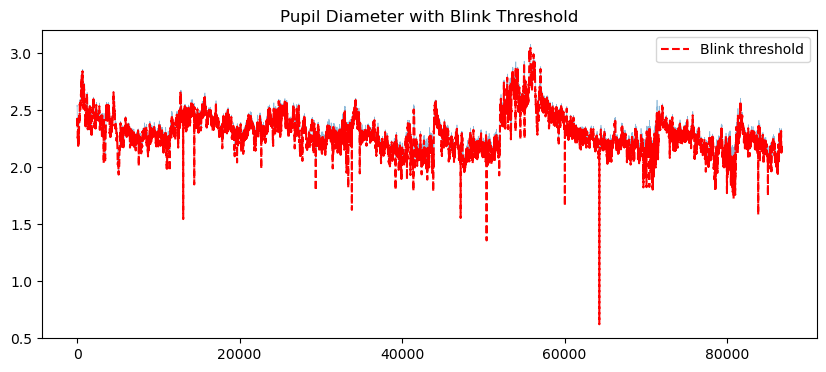

In [ ]:
# Total number of fixations: 2627
# Total number of saccades: 2627
# Total number of blinks: 642
# Total number of noise samples: 733

#This is using the pupil diameter threshold not allowing the invalid samples only
plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.5, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='--', label='Blink threshold')
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

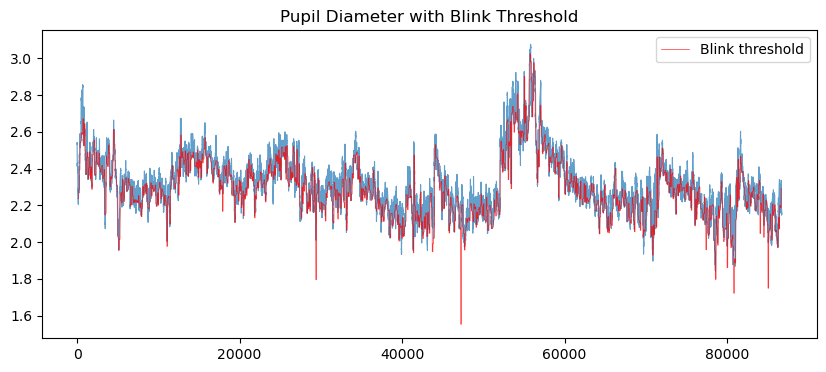

In [ ]:
# Total number of fixations: 2627
# Total number of saccades: 2627
# Total number of blinks: 66
# Total number of noise samples: 548

#This is using the pupil diameter threshold with a 90 samples recalculation
plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.7, linewidth=0.8)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', alpha=0.8, linewidth=0.5)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

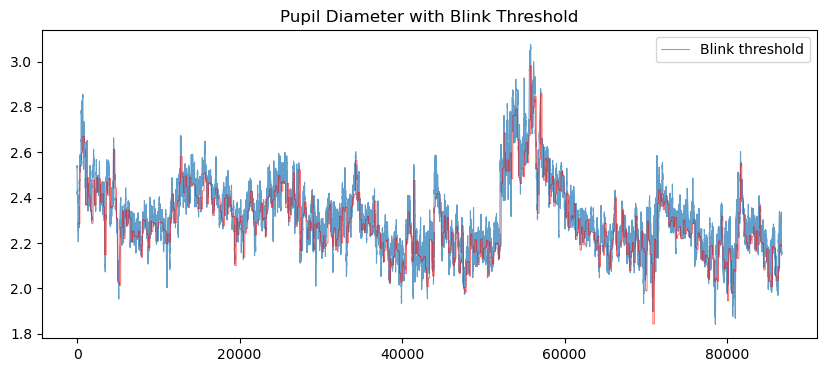

In [ ]:

#This is using the pupil diameter threshold with a 180 samples recalculation
plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.7, linewidth=0.8)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', alpha=0.8, linewidth=0.5)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

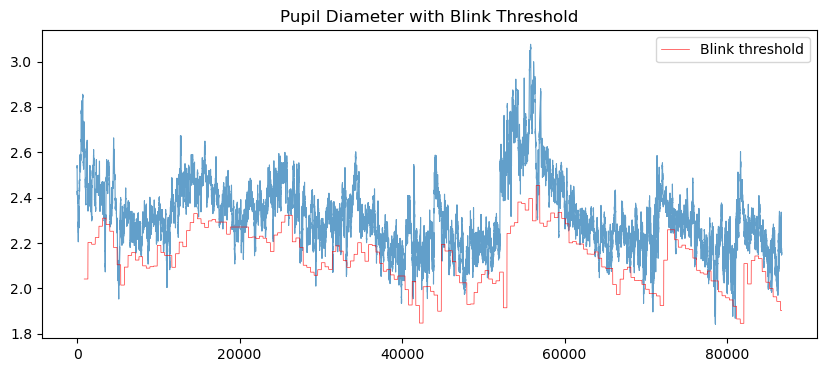

In [ ]:

#This is using the pupil diameter threshold using 10s samples and recalculating every 5 seconds
plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.7, linewidth=0.8)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', alpha=0.8, linewidth=0.5)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

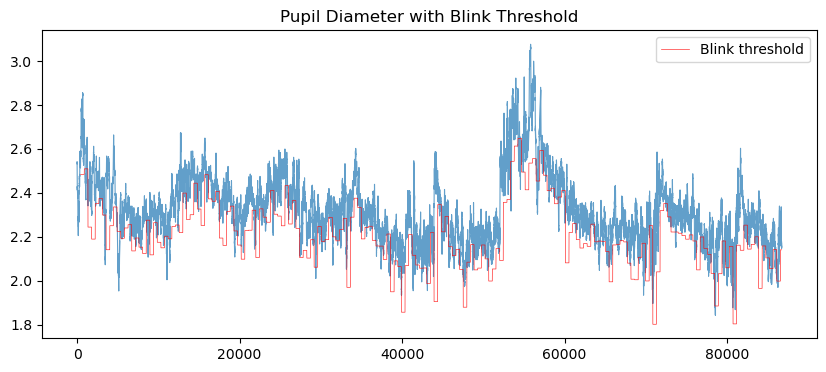

In [ ]:

#This is using the pupil diameter threshold using 1s samples and recalculating every 5 seconds is_invalid
plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.7, linewidth=0.8)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', alpha=0.8, linewidth=0.5)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

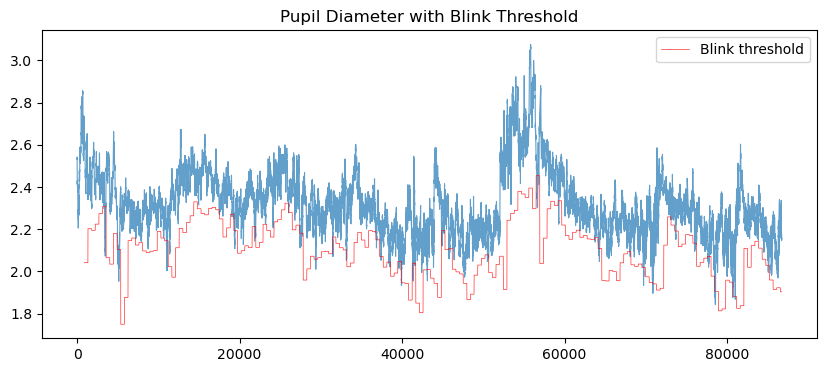

In [ ]:
# Total number of blinks: 19
# Total number of noise samples: 114

#This is using the pupil diameter threshold using 10s samples and recalculating every 5 seconds is_invalid
plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.7, linewidth=0.8)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', alpha=0.8, linewidth=0.5)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

### TESTING

In [113]:
processed_samples = pd.read_csv("../data/processed/processed_samples.csv")
processed_samples["relative_time_s"] = (processed_samples["ts_ms"] - processed_samples["ts_ms"].iloc[0]) / 1000
processed_samples.columns

Index(['Unnamed: 0', 'ts_ms', 'raw_x', 'raw_y', 'gaze_point', 'gaze_origin',
       'gaze_origin_z', 'pupil_diameter', 'pupil_affected', 'is_fixation',
       'angle_degree', 'velocity', 'ripa2', 'blink_threshold',
       'relative_time_s'],
      dtype='object')

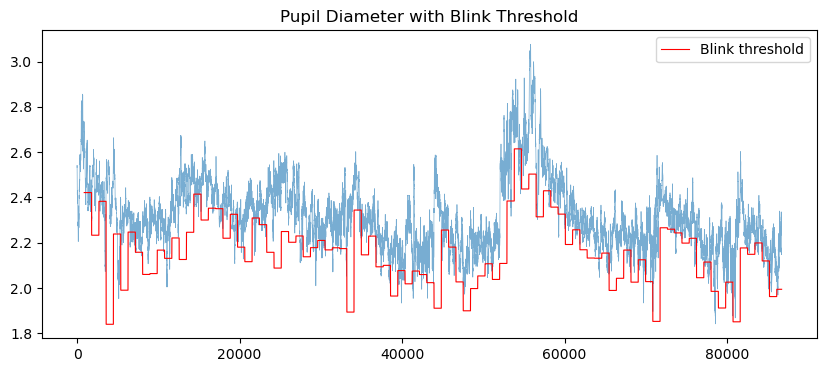

In [114]:
# Total number of blinks: 92
# Total number of noise samples: 132

# reaclculate every 900 - 10 seconds
# queue max len 180 - 2 seconds
# if not event["is_invalid"]
# max duration 400 
# without setting the previous/next 9 samples as invalid
# checking that the baseline buffer does not contain any invalid samples when recalculating the threshold

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.6, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

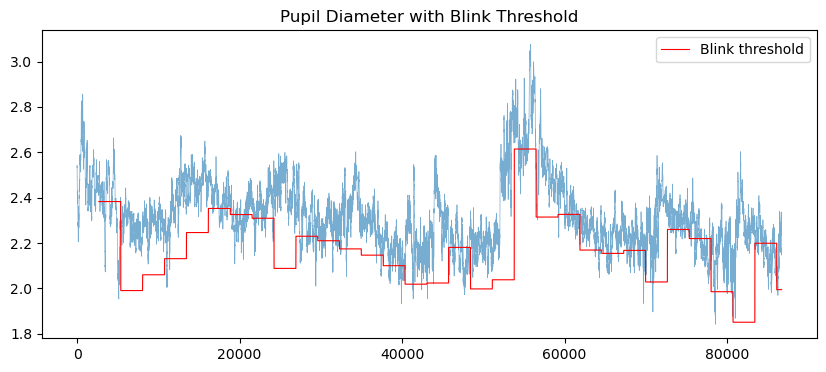

In [ ]:
# Total number of blinks: 106
# Total number of noise samples: 150

# reaclculate every 2700 - 30 seconds
# queue max len 180 - 2 seconds
# if not event["is_invalid"]
# max duration 400 
# without setting the previous/next 9 samples as invalid
# checking that the baseline buffer does not contain any invalid samples when recalculating the threshold

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.6, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

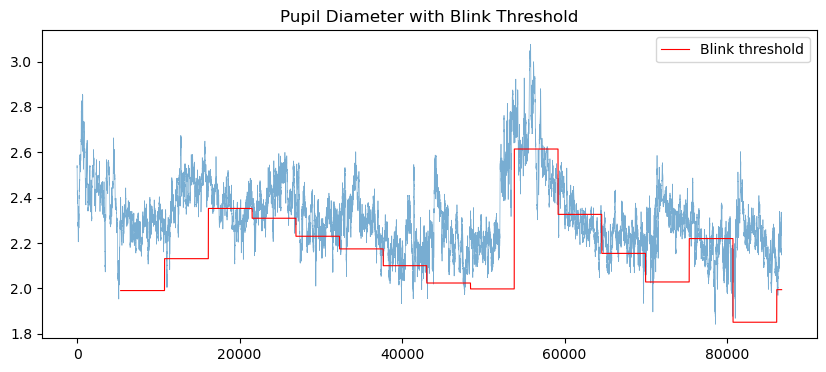

In [ ]:
# Total number of blinks: 96
# Total number of noise samples: 144

# reaclculate every 5400 - 1 minute
# queue max len 180 - 2 seconds
# if not event["is_invalid"]
# max duration 400 
# without setting the previous/next 9 samples as invalid
# checking that the baseline buffer does not contain any invalid samples when recalculating the threshold

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.6, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

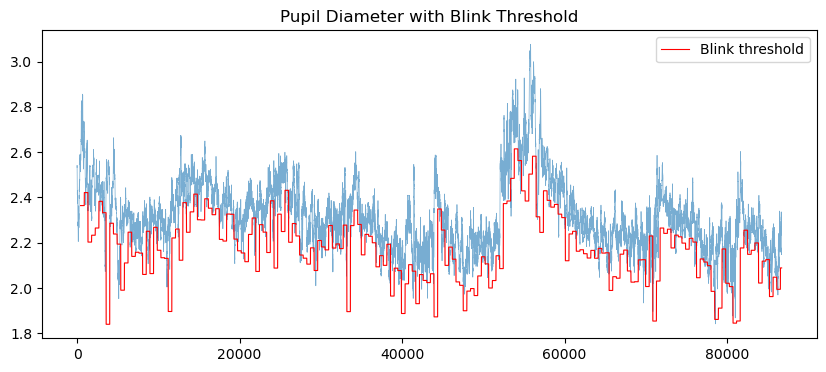

In [ ]:
# Total number of blinks: 96
# Total number of noise samples: 136

# reaclculate every 450 - 5 second
# queue max len 180 - 2 seconds
# if not event["is_invalid"]
# max duration 400 
# without setting the previous/next 9 samples as invalid

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.6, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

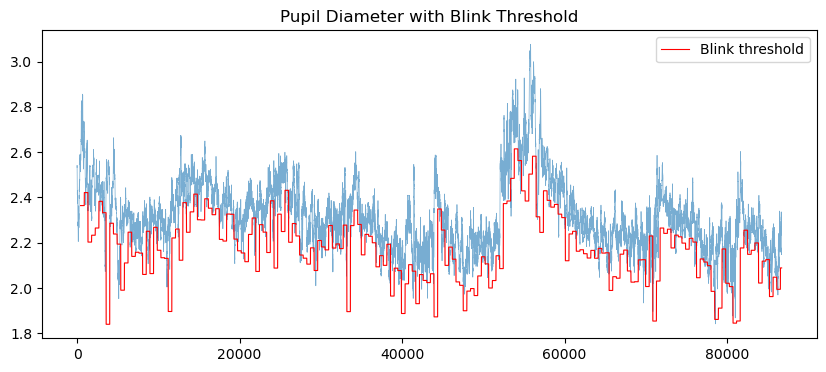

In [104]:
# Total number of blinks: 30
# Total number of noise samples: 178

# reaclculate every 450 - 5 second
# queue max len 180 - 2 seconds
# if not event["is_invalid"]

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.6, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

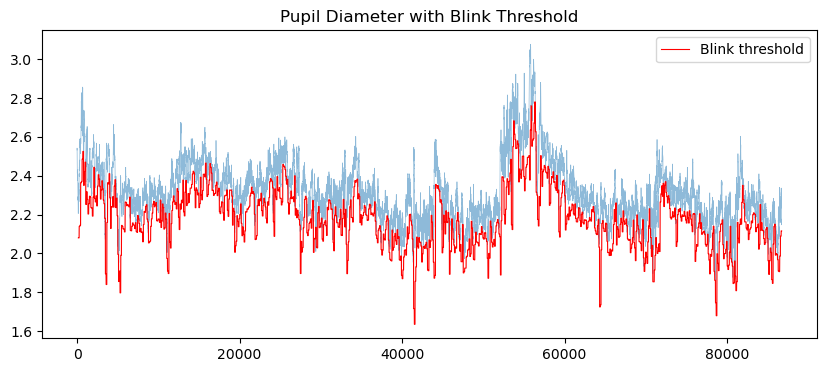

In [100]:
# Total number of blinks: 38
# Total number of noise samples: 189

# reaclculate every 90 - 1 second
# queue max len 180 - 2 seconds
# if not event["is_invalid"]

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.5, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

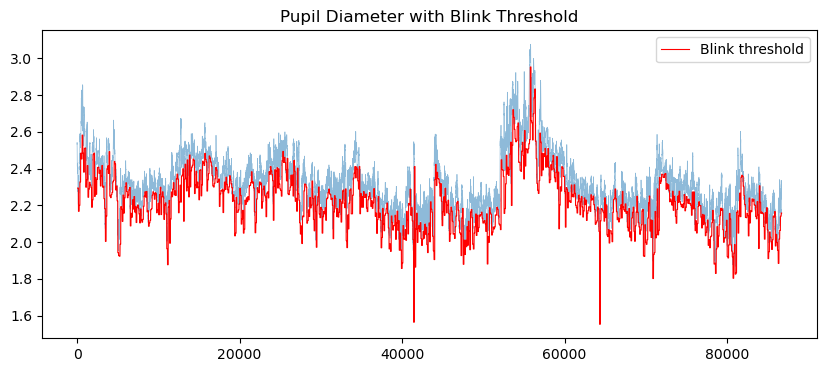

In [98]:
# Total number of blinks: 39
# Total number of noise samples: 297

# reaclculate every 90 - 1 second
# queue max len 90 - 1 seconds
# if not event["is_invalid"]

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.5, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

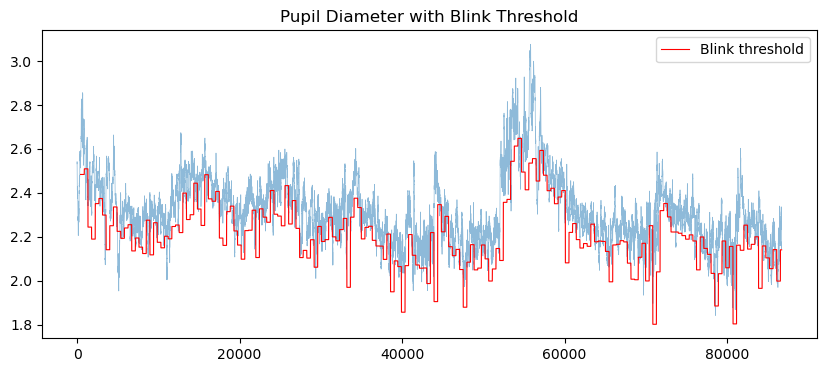

In [ ]:
# Total number of blinks: 30
# Total number of noise samples: 227

# reaclculate every 450 - 5 second
# queue max len 90 - 1 seconds
# if not event["is_invalid"]

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.5, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

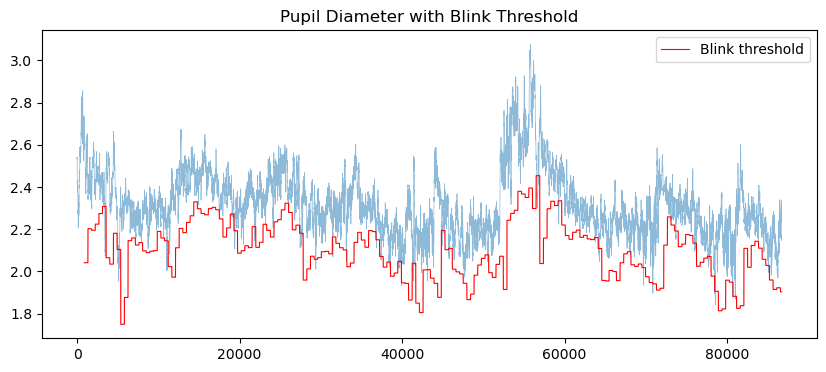

In [93]:
# Total number of blinks: 13
# Total number of noise samples: 89

# reaclculate every 450 - 5 second
# queue max len 900 - 10 seconds
# if not event["is_invalid"]

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.5, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

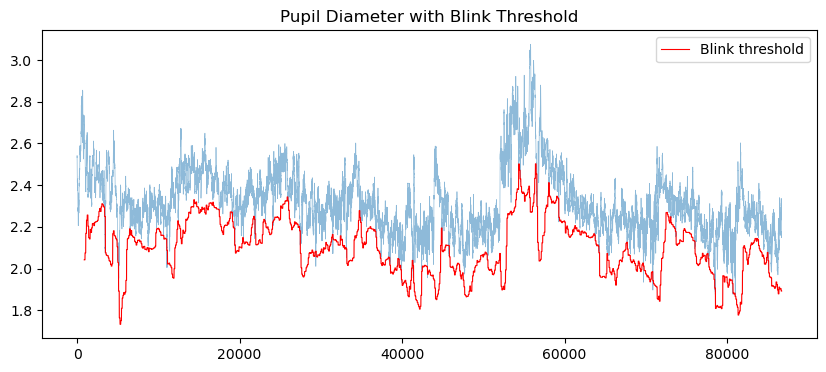

In [91]:
# Total number of blinks: 23
# Total number of noise samples: 79

# reaclculate every 90 - 1 second
# queue max len 900 - 10 seconds
# if not event["is_invalid"]

plt.figure(figsize=(10, 4))
plt.plot(processed_samples['pupil_diameter'], alpha=0.5, linewidth=0.5)
plt.plot(processed_samples['blink_threshold'], color='red', linestyle='-', label='Blink threshold', linewidth=0.8)
plt.legend()
plt.title('Pupil Diameter with Blink Threshold')
plt.show()

### Hampel Filter

A few randomly selected samples to showcase how the Hampel filter works

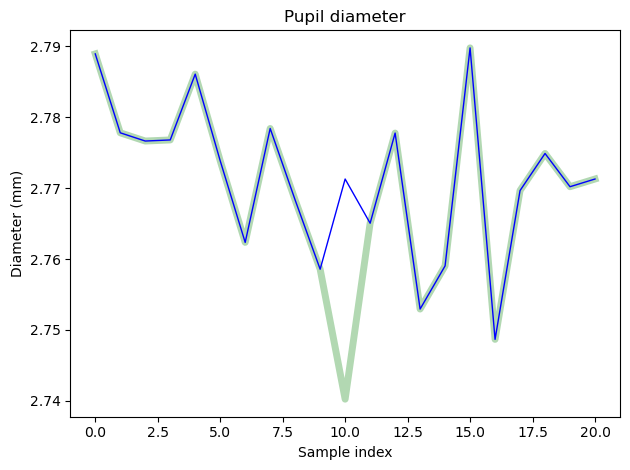

In [9]:
old_data = [2.7889175, 2.777794, 2.7766339999999996, 2.7767865, 2.7860639999999997, 2.7738495, 2.7623439999999997, 2.7784044999999997, 2.7683105, 2.75856, 2.740242, 2.7650449999999998, 2.777756, 2.752945, 2.759033, 2.7897645, 2.7486725, 2.769653, 2.7748795, 2.770195, 2.7712785]
new_data = [2.7889175, 2.777794, 2.776634, 2.7767866, 2.786064, 2.7738495, 2.762344, 2.7784045, 2.7683105, 2.75856, 2.7712784, 2.765045, 2.777756, 2.752945, 2.759033, 2.7897644, 2.7486725, 2.769653, 2.7748795, 2.770195, 2.7712784]

plt.plot(old_data, color='green', linewidth=5, alpha=0.3)
plt.plot(new_data, color='blue', linewidth=1)
plt.xlabel('Sample index')
plt.ylabel('Diameter (mm)')
plt.title('Pupil diameter')
plt.tight_layout()
plt.show()

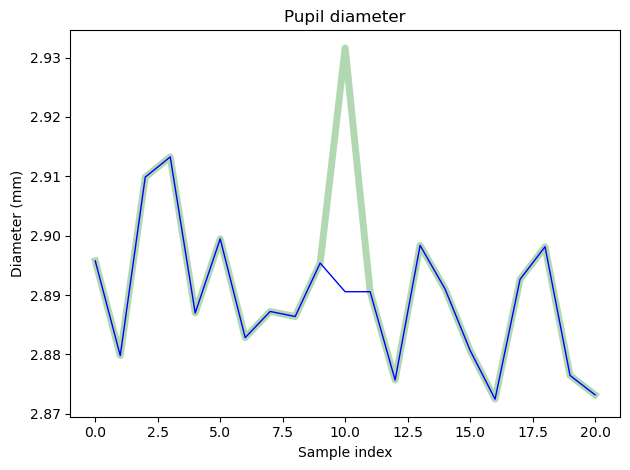

In [10]:
old_data = [2.8957445, 2.879799, 2.9098664999999997, 2.913269, 2.8869705, 2.8994675, 2.8828199999999997, 2.8872299999999997, 2.886375, 2.895386, 2.9316405, 2.890556, 2.8756715, 2.898361, 2.8910065, 2.8806839999999996, 2.8724515, 2.892639, 2.8981399999999997, 2.8764495, 2.873184]
new_data = [2.8957446, 2.879799, 2.9098666, 2.913269, 2.8869705, 2.8994675, 2.88282, 2.88723, 2.886375, 2.895386, 2.890556, 2.890556, 2.8756714, 2.898361, 2.8910065, 2.880684, 2.8724515, 2.892639, 2.89814, 2.8764496, 2.873184]

plt.plot(old_data, color='green', linewidth=5, alpha=0.3)
plt.plot(new_data, color='blue', linewidth=1)
plt.xlabel('Sample index')
plt.ylabel('Diameter (mm)')
plt.title('Pupil diameter')
plt.tight_layout()
plt.show()

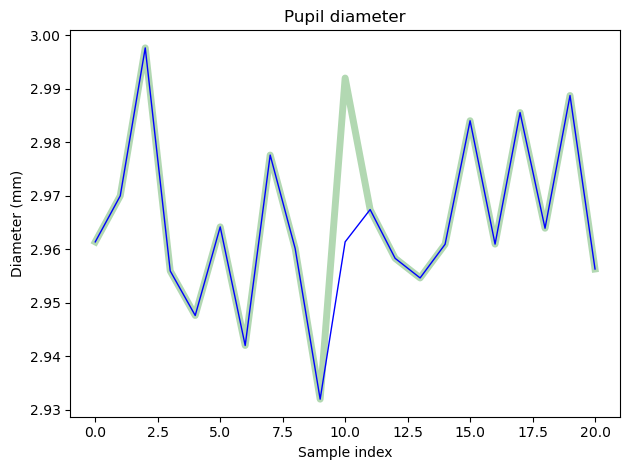

In [11]:
old_data = [2.9613875, 2.969994, 2.997658, 2.9559480000000002, 2.9476240000000002, 2.964188, 2.9420165000000003, 2.9776154999999997, 2.9601439999999997, 2.9319759999999997, 2.9920194999999996, 2.9674300000000002, 2.958313, 2.954643, 2.9609375, 2.9840394999999997, 2.9609680000000003, 2.9855650000000002, 2.963936, 2.9887544999999998, 2.956314]
new_data = [2.9613874, 2.969994, 2.997658, 2.955948, 2.947624, 2.964188, 2.9420166, 2.9776156, 2.960144, 2.931976, 2.9613874, 2.96743, 2.958313, 2.954643, 2.9609375, 2.9840395, 2.960968, 2.985565, 2.963936, 2.9887545, 2.956314]

plt.plot(old_data, color='green', linewidth=5, alpha=0.3)
plt.plot(new_data, color='blue', linewidth=1)
plt.xlabel('Sample index')
plt.ylabel('Diameter (mm)')
plt.title('Pupil diameter')
plt.tight_layout()
plt.show()

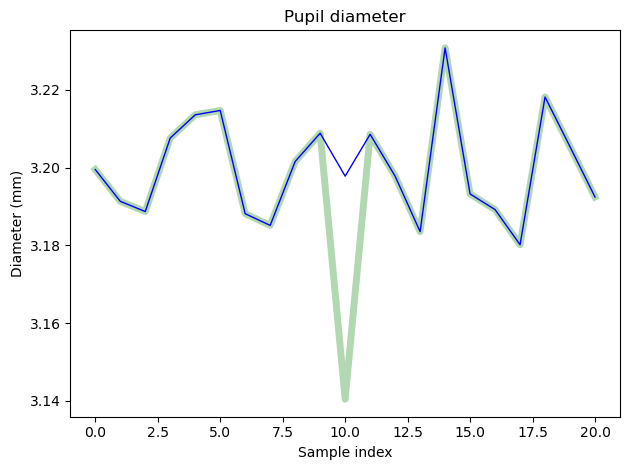

In [12]:
old_data = [3.1994705000000003, 3.1913145, 3.1886824999999996, 3.2075804999999997, 3.2135395000000004, 3.214653, 3.1881255, 3.1851275, 3.201546, 3.2088085, 3.140472, 3.208534, 3.1977770000000003, 3.1835175, 3.230736, 3.1932065, 3.1891785, 3.1801605, 3.2181170000000003, 3.20533, 3.192413]
new_data = [3.1994705, 3.1913145, 3.1886826, 3.2075806, 3.2135396, 3.214653, 3.1881256, 3.1851275, 3.201546, 3.2088084, 3.197777, 3.208534, 3.197777, 3.1835175, 3.230736, 3.1932065, 3.1891785, 3.1801605, 3.218117, 3.20533, 3.192413]

plt.plot(old_data, color='green', linewidth=5, alpha=0.3)
plt.plot(new_data, color='blue', linewidth=1)
plt.xlabel('Sample index')
plt.ylabel('Diameter (mm)')
plt.title('Pupil diameter')
plt.tight_layout()
plt.show()

### Distance to Screen

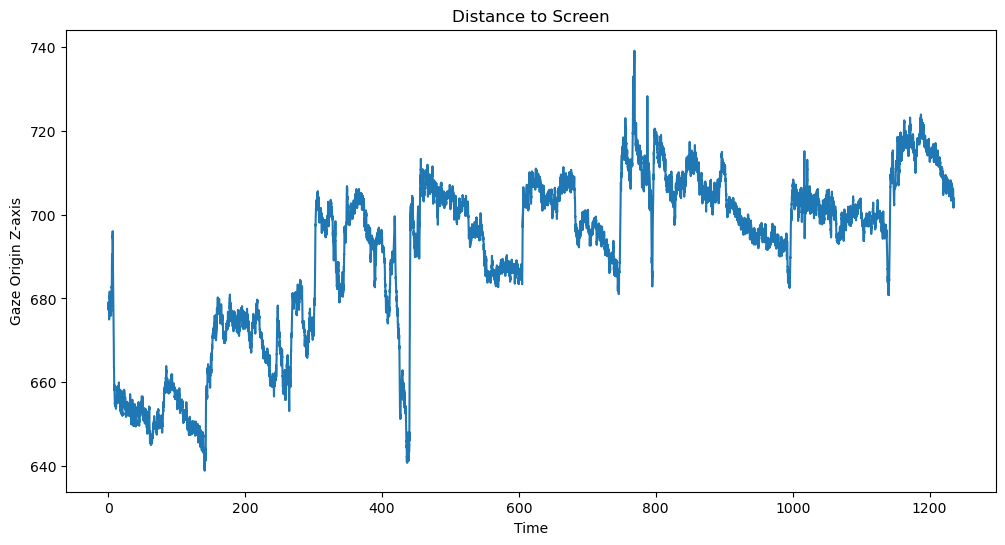

In [86]:
# Saccade length over time
plt.figure(figsize=(12, 6))
plt.plot(processed_samples["relative_time_s"], processed_samples["gaze_origin_z"], label="Distance to Screen")
plt.title("Distance to Screen")
plt.xlabel("Time")
plt.ylabel("Gaze Origin Z-axis")
plt.show()

### Saccade Length

In [17]:
# saccades = saccades[saccades['duration'] < 11]
saccades = saccades[saccades['length'] < 50] # too high
saccades = saccades[saccades['length'] > 10] # wouldn't that be the same word if lenght 0? or should we be merging saccades?

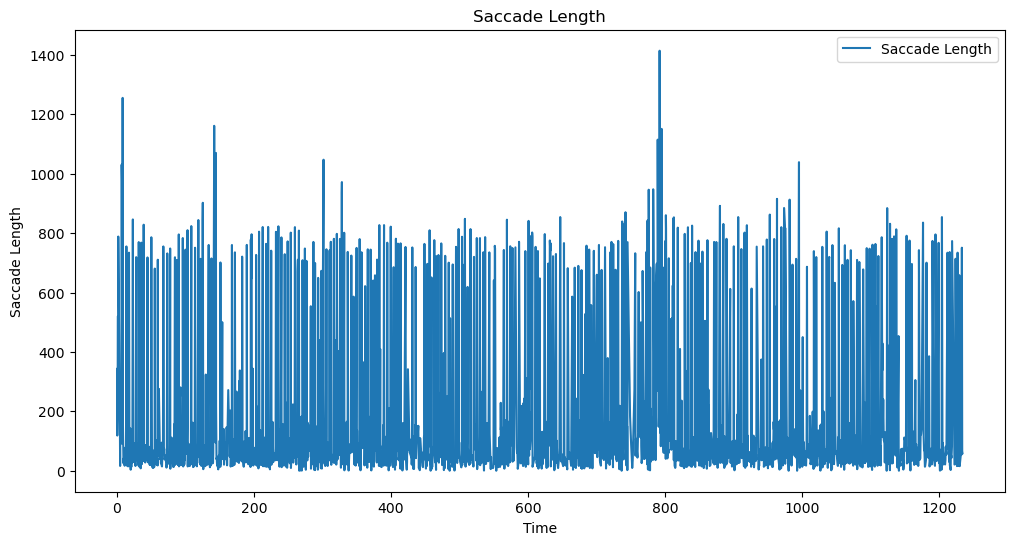

In [22]:
# Saccade length over time
plt.figure(figsize=(12, 6))
plt.plot(saccades["relative_time_s"], saccades["length"], label="Saccade Length")
plt.title("Saccade Length")
plt.xlabel("Time")
plt.ylabel("Saccade Length")
plt.legend()
plt.show()

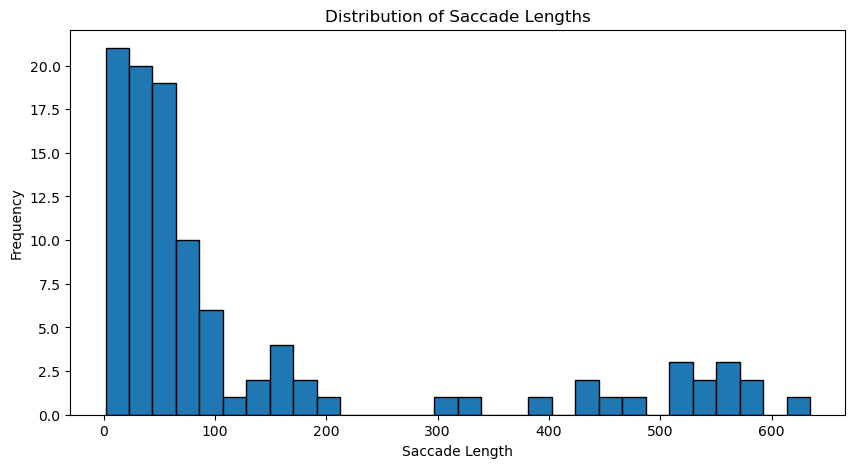

In [66]:
# Distribution of saccade lengths
plt.figure(figsize=(10, 5))
plt.hist(saccades["length"], bins=30, edgecolor='black')
plt.title("Distribution of Saccade Lengths")
plt.xlabel("Saccade Length")
plt.ylabel("Frequency")
plt.show() 

### Saccade velocity

In [59]:
saccades = saccades[saccades["peak_velocity"] < 80]

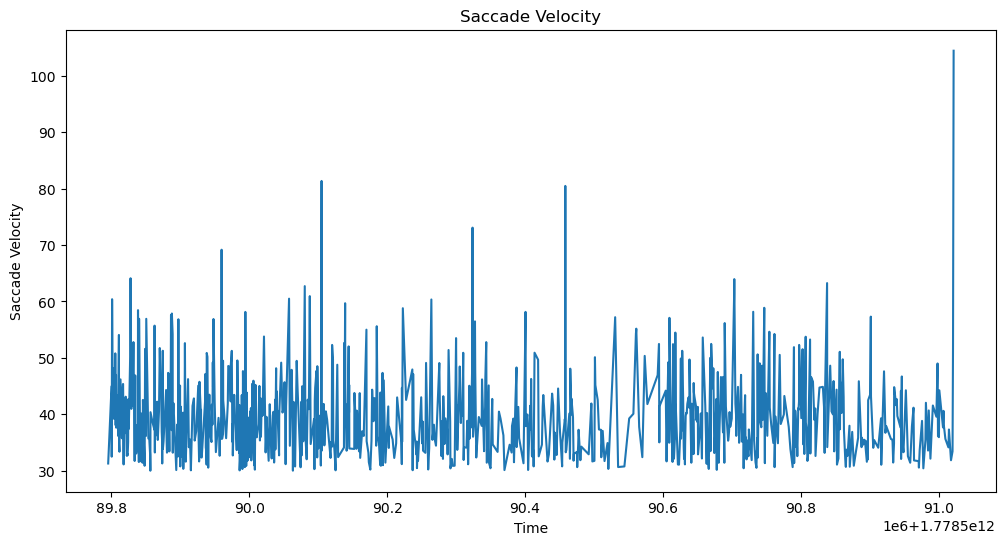

In [19]:
# Saccade length over time
plt.figure(figsize=(12, 6))
plt.plot(saccades["start_time"], saccades["peak_velocity"], label="Saccade Velocity")
plt.title("Saccade Velocity")
plt.xlabel("Time")
plt.ylabel("Saccade Velocity")
plt.show()

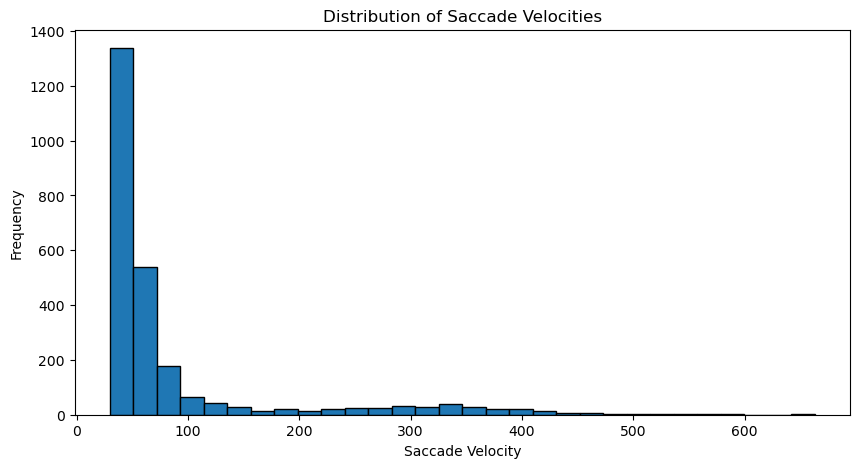

In [23]:
# Distribution of saccade velocity
plt.figure(figsize=(10, 5))
plt.hist(saccades["peak_velocity"], bins=30, edgecolor='black')
plt.title("Distribution of Saccade Velocities")
plt.xlabel("Saccade Velocity")
plt.ylabel("Frequency")
plt.show() 

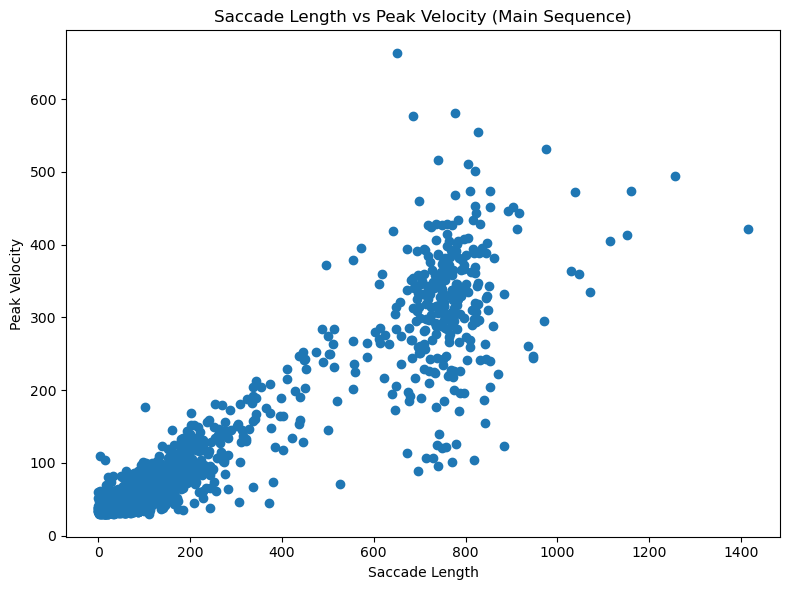

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(saccades['length'], saccades['peak_velocity'])
plt.xlabel('Saccade Length')
plt.ylabel('Peak Velocity')
plt.title('Saccade Length vs Peak Velocity (Main Sequence)')
plt.tight_layout()
plt.show()

The zeros and near-zeros in saccade length are the main issue!!

### RIPA2

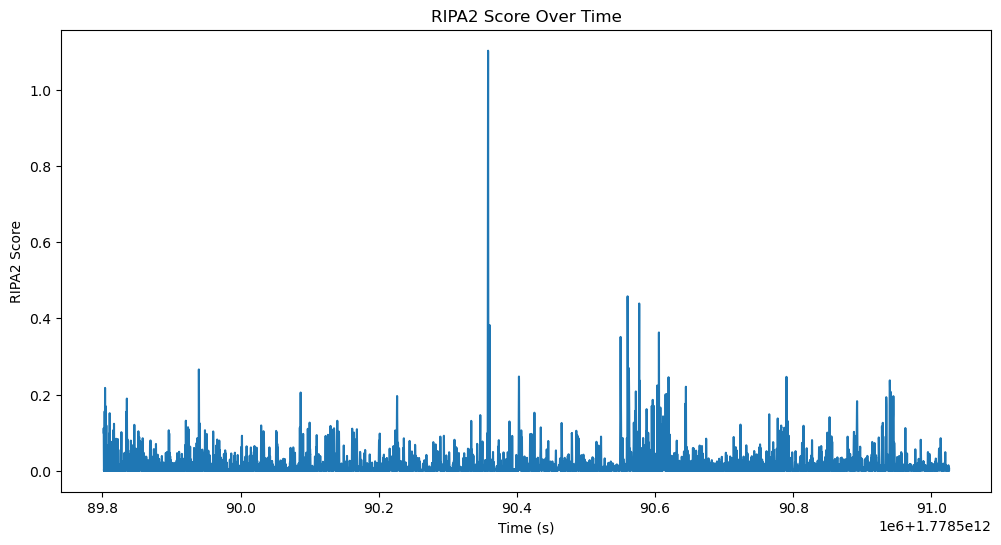

In [25]:
#with
plt.figure(figsize=(12, 6))
plt.plot(processed_samples["ts_ms"], processed_samples["ripa2"])
plt.title("RIPA2 Score Over Time")
plt.xlabel("Time (s)")
plt.ylabel("RIPA2 Score")
plt.show()

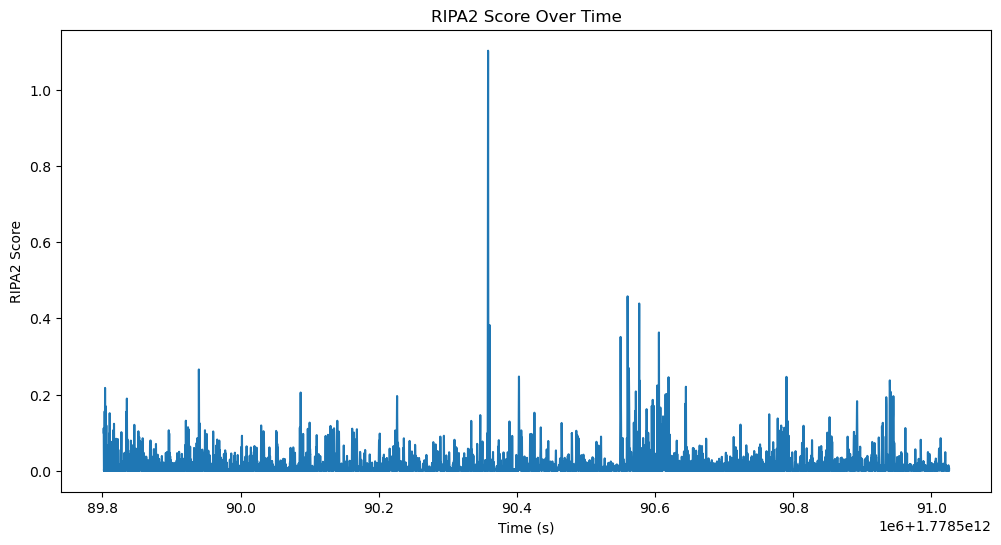

In [26]:
#without
plt.figure(figsize=(12, 6))
plt.plot(processed_samples["ts_ms"], processed_samples["ripa2"])
plt.title("RIPA2 Score Over Time")
plt.xlabel("Time (s)")
plt.ylabel("RIPA2 Score")
plt.show()

In [46]:
processed_samples = processed_samples[processed_samples["ripa2"] > 0]

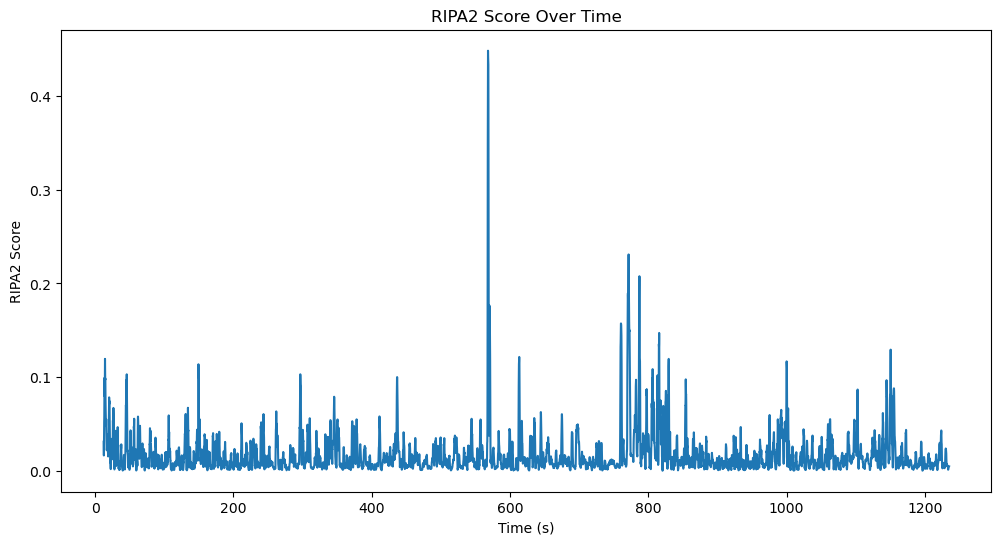

In [27]:
#with
#  RIPA2 score over time

processed_samples["smoothed_ripa2"] = processed_samples['ripa2'].rolling(90).mean()

plt.figure(figsize=(12, 6))
plt.plot(processed_samples["relative_time_s"], processed_samples["smoothed_ripa2"])
plt.title("RIPA2 Score Over Time")
plt.xlabel("Time (s)")
plt.ylabel("RIPA2 Score")
plt.show()

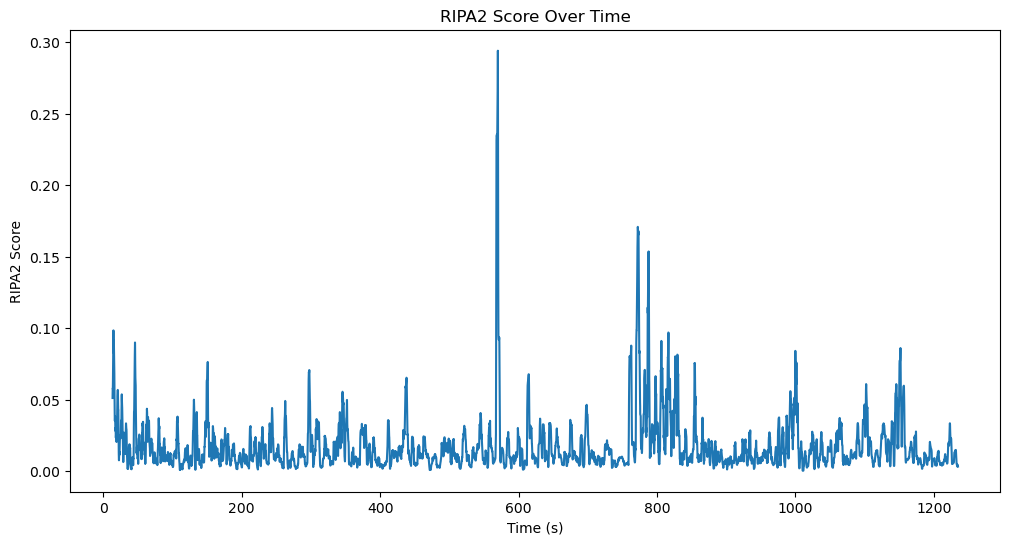

In [28]:
#without
# RIPA2 score over time
processed_samples["smoothed_ripa2"] = processed_samples['ripa2'].rolling(180).mean()

plt.figure(figsize=(12, 6))
plt.plot(processed_samples["relative_time_s"], processed_samples["smoothed_ripa2"])
plt.title("RIPA2 Score Over Time")
plt.xlabel("Time (s)")
plt.ylabel("RIPA2 Score")
plt.show()

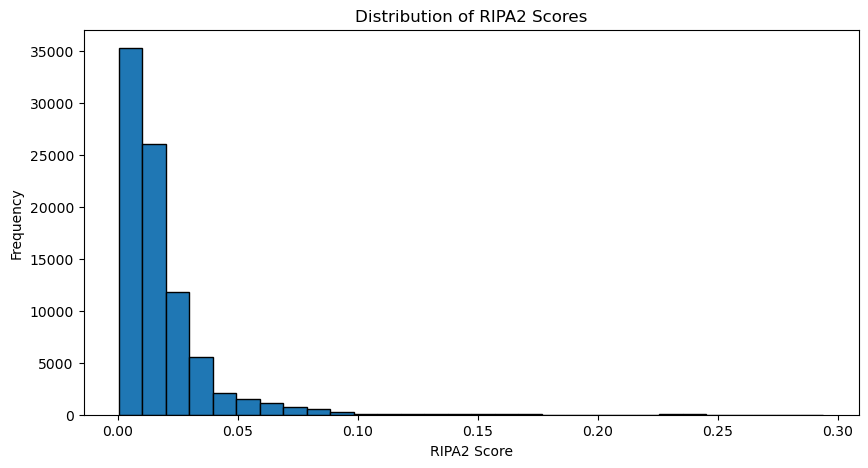

In [29]:
# Distribution of RIPA2
plt.figure(figsize=(10, 5))
plt.hist(processed_samples["smoothed_ripa2"], bins=30, edgecolor='black')
plt.title("Distribution of RIPA2 Scores")
plt.xlabel("RIPA2 Score")
plt.ylabel("Frequency")
plt.show()

### Blink rate

In [10]:
blinks.columns

Index(['Start time', 'End time', 'Duration', 'Blink rate', 'relative_time_s'], dtype='object', name='Unnamed: 0')

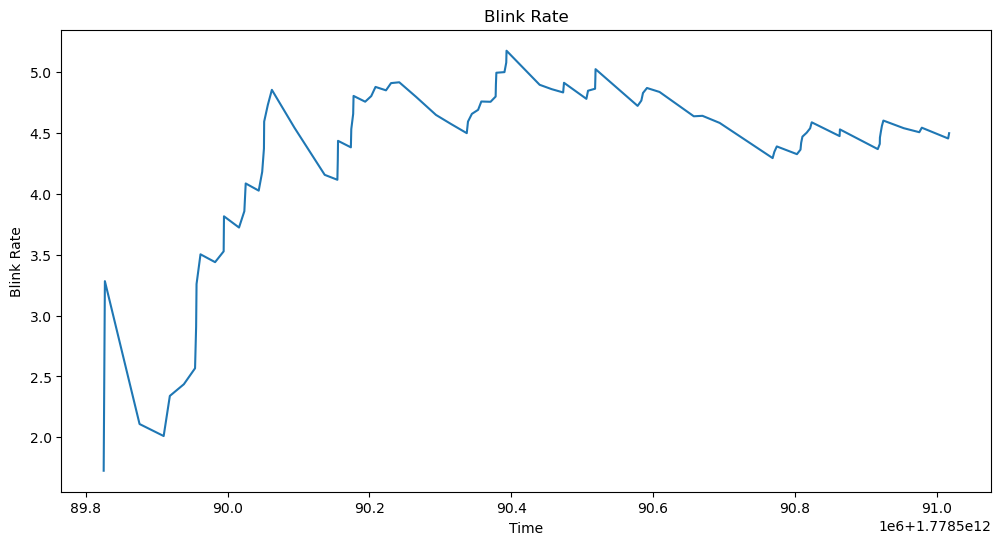

In [11]:
# Saccade length over time
plt.figure(figsize=(12, 6))
plt.plot(blinks["Start time"], blinks["Blink rate"], label="Blink rate")
plt.title("Blink Rate")
plt.xlabel("Time")
plt.ylabel("Blink Rate")
plt.show()

### Fixation duration

In [90]:
fixations = fixations[fixations["fixation_duration"] > 80]
# fixations = fixations[fixations["fixation_duration"] < 5000]

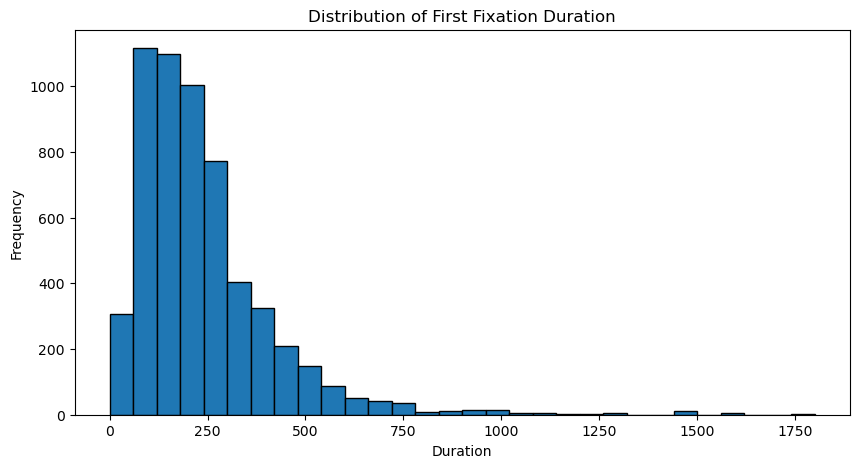

In [91]:
plt.figure(figsize=(10, 5))
plt.hist(fixations["first_fixation_duration"], bins=30, edgecolor='black')
plt.title("Distribution of First Fixation Duration")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show() 

In [96]:
# MECO filters < 80 ms first fix durations

'''
For the purposes of reliability and descrip>ve analyses below, further data cleaning involved
removing data points that showed very short (< 80 ms) first fixa>ons, which are unlikely to provide
suﬃcient >me to complete visual uptake (see Warren et al., 2009), or very long total fixa>on >mes (top
1% of the par>cipant-specific distribu>on, all exceeding 3s on the word).
'''

fixations = fixations[fixations["first_fixation_duration"] >= 80]

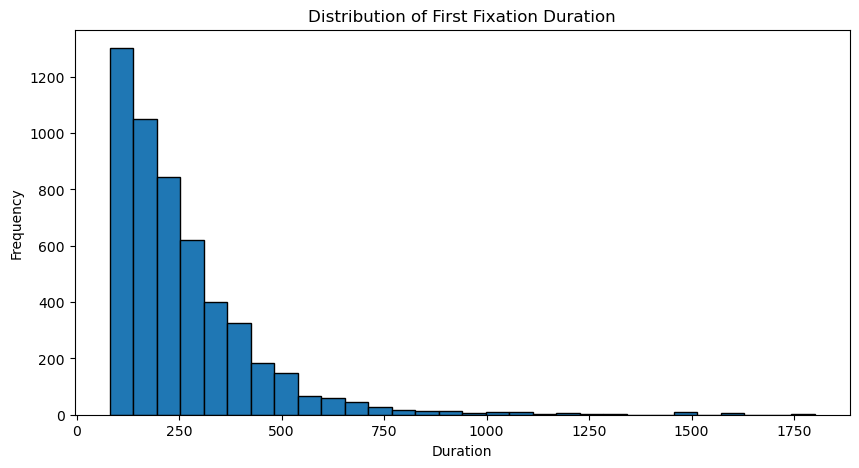

In [97]:
plt.figure(figsize=(10, 5))
plt.hist(fixations["first_fixation_duration"], bins=30, edgecolor='black')
plt.title("Distribution of First Fixation Duration")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show() 

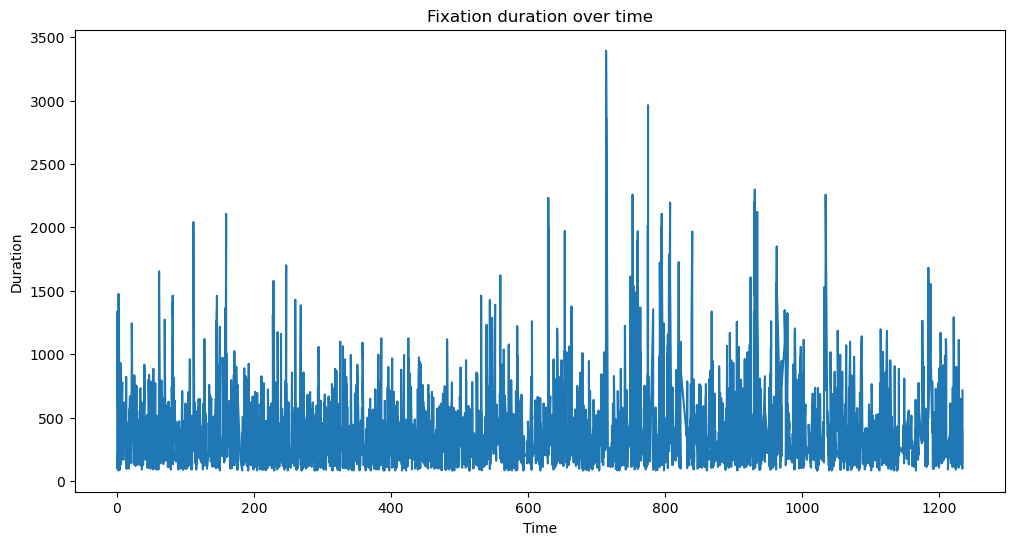

In [98]:
plt.figure(figsize=(12, 6))
plt.plot(fixations["relative_time_s"], fixations["fixation_duration"])
plt.title("Fixation duration over time")
plt.xlabel("Time")
plt.ylabel("Duration")
plt.show()

In [102]:
len(fixations["fixation_group_numbers"].unique())

4766

In [104]:
# fixations = pd.read_csv("../data/processed/fixations.csv")
# fixations['relative_time_s'] = (fixations["first_time"] - fixations['first_time'].iloc[0]) / 1000
# fixations = fixations.sort_values("first_time")
fixations.columns

Index(['Unnamed: 0',
       '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc:25:sentence:12:word:8',
       '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc:25:sentence:18:word:20',
       '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc:24:sentence:1:word:7',
       '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc:22:sentence:2:word:15',
       '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc:22:sentence:1:word:3',
       '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc:24:sentence:3:word:2',
       '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc:2:sentence:3:word:14',
       '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc:2:sentence:1:word:3',
       '235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54ce2ab2fa0e7b77625cc:2:sentence:1:word:8',
       ...
       '235217fae96e47708c30c9e6b59cf7cb:2b6070dd57954d56898a7864d397035c:15:sentence:3:word:

In [105]:
len(fixations)

1383

## CL Clustering

In [7]:
import rdata
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle

fixations_data = rdata.read_rda("../data/raw/joint_l2_fixation_trimmed_report_2.0.rda")["joint.fix.l2"]
fixations_data = fixations_data[fixations_data["lang"] != "en"]
fixations_data = fixations_data[fixations_data["dur"] > 80 | fixations_data["dur"].isna()]
# Index(['subid', 'trialid', 'trialnum', 'itemid', 'cond', 'fixid', 'start',
#    'stop', 'xs', 'ys', 'xn', 'yn', 'ym', 'dur', 'ps', 'sac.in', 'sac.out',
#    'type', 'blink', 'line', 'line.change', 'line.let', 'line.word',
#    'letternum', 'letter', 'wordnum', 'word', 'ianum', 'ia', 'sentnum',
#    'sent', 'sent.nwords', 'trial', 'trial.nwords', 'word.fix', 'word.run',
#    'word.runid', 'word.run.fix', 'word.firstskip', 'word.refix',
#    'word.launch', 'word.land', 'word.cland', 'word.reg.out', 'word.reg.in',
#    'word.reg.out.to', 'word.reg.in.from', 'ia.fix', 'ia.run', 'ia.runid',
#    'ia.run.fix', 'ia.firstskip', 'ia.refix', 'ia.launch', 'ia.land',
#    'ia.cland', 'ia.reg.out', 'ia.reg.in', 'ia.reg.out.to',
#    'ia.reg.in.from', 'sent.word', 'sent.fix', 'sent.run', 'sent.runid',
#    'sent.run.fix', 'sent.firstskip', 'sent.refix', 'sent.reg.out',
#    'sent.reg.in', 'sent.reg.out.to', 'sent.reg.in.from', 'lang',
#    'uniform_id'],
#   dtype='object')

In [3]:
saccades_data = rdata.read_rda("../data/raw/joint_L2_sac_trimmed_wave1_2.0.rda")["joint.sac.l2"]
saccades_data = saccades_data[saccades_data["lang"] != "en"]
saccades_data = saccades_data[saccades_data["msg"] == "SAC"]
# Index(['subid', 'trialid', 'trialnum', 'itemid', 'cond', 'sacid', 'msg', 'xs',
#    'xe', 'ys', 'ye', 'xsn', 'xen', 'ysn', 'yen', 'start', 'stop', 'dur',
#    'lines', 'linee', 'dist.line', 'lets', 'lete', 'dist.let', 'dx', 'dy',
#    'dist.px', 'amp.px', 'amp.deg', 'pv.px', 'pv.deg', 'lang',
#    'uniform_id'],
#   dtype='object')

In [355]:
saccades_data.iloc[:, 19:35]

,linee,dist.line,lets,lete,dist.let,dx,dy,dist.px,amp.px,amp.deg,pv.px,pv.deg,lang,uniform_id,window_start,window_end
1,5.0,0.0,3.0,13.0,10.0,157.6,21.1,159.0,166.0,2.19,15974.0,234.0,du,du_4,12001.0,14000.0
2,5.0,0.0,13.0,28.0,15.0,235.0,-0.1,235.0,254.0,3.45,20789.0,323.0,du,du_4,14001.0,16000.0
3,4.0,0.0,53.0,66.0,13.0,206.3,-3.9,206.0,218.0,3.14,18818.0,285.0,du,du_4,10001.0,12000.0
4,4.0,0.0,66.0,62.0,-4.0,-64.3,12.6,66.0,90.0,0.91,8681.0,135.0,du,du_4,10001.0,12000.0
5,4.0,0.0,62.0,60.0,-2.0,-27.4,0.7,27.0,33.0,0.57,4162.0,60.0,du,du_4,10001.0,12000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215644,8.0,0.0,11.0,14.0,3.0,52.9,2.5,53.0,60.0,1.33,5106.0,103.0,tr,tr_52,60001.0,62000.0
1215645,8.0,0.0,14.0,19.0,5.0,61.7,-6.9,62.0,74.0,1.62,6705.0,132.0,tr,tr_52,60001.0,62000.0
1215646,8.0,0.0,19.0,26.0,7.0,114.1,1.0,114.0,127.0,2.81,9350.0,198.0,tr,tr_52,62001.0,64000.0
1215648,8.0,0.0,32.0,37.0,5.0,84.4,5.1,85.0,89.0,2.03,7534.0,155.0,tr,tr_52,62001.0,64000.0


In [8]:
print("Length of word-level data:", len(fixations_data))
print("Length of saccades data:", len(saccades_data))

Length of word-level data: 1137404
Length of saccades data: 1066306


In [343]:
saccades_data['start']

1          13998.0
2          14179.0
3          11449.0
4          11630.0
5          11880.0
            ...   
1215644    61522.0
1215645    61782.0
1215646    62088.0
1215648    62604.0
1215649    62736.0
Name: start, Length: 1066306, dtype: float64

In [356]:
print(fixations_data['word.reg.out'].describe())
print(fixations_data['word.reg.out'].value_counts().head())

count    1.137404e+06
mean     1.506738e-01
std      3.577308e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: word.reg.out, dtype: float64
word.reg.out
0.0    966027
1.0    171377
Name: count, dtype: int64


In [345]:
fixations_df['fixation_rate']

0         0.300000
1         0.300000
2         0.290000
3         0.285000
4         0.270000
            ...   
150894    0.269062
150895    0.269091
150896    0.268235
150897    0.267429
150898    0.261667
Name: fixation_rate, Length: 150899, dtype: float64

In [346]:
print(fixations_df[['window_start', 'window_end', 'num_fixations', 'fixation_rate']].head(10))

   window_start  window_end  num_fixations  fixation_rate
0           1.0      2000.0             10       0.300000
1        2001.0      4000.0             20       0.300000
2        4001.0      6000.0             29       0.290000
3        6001.0      8000.0             38       0.285000
4        8001.0     10000.0             45       0.270000
5       10001.0     12000.0             54       0.270000
6       12001.0     14000.0             63       0.270000
7       14001.0     16000.0             71       0.266250
8       16001.0     18000.0             80       0.266667
9       18001.0     20000.0             88       0.264000


In [347]:
window_size = 2000

# Building a fixations dataframe with cumulative means for duration and frequency of regression
fixations_data['window_start'] = ((fixations_data['start'] - 1) // window_size) * window_size + 1
fixations_data['window_end'] = fixations_data['window_start'] + window_size - 1

fixations_df = (fixations_data.groupby(['subid', 'trialnum', 'window_start', 'window_end']).agg(
    fixation_duration=('dur', 'mean'),
    num_fixations=('dur', 'count'),
    frequency_of_regression=('word.reg.in', 'mean'),
    ).reset_index()).sort_values(['subid', 'trialnum', 'window_start'])

cumulative_cols = ['fixation_duration', 'frequency_of_regression']
fixations_df[cumulative_cols] = (
    fixations_df.groupby(['subid', 'trialnum'])[cumulative_cols]
    .expanding()
    .mean()
    .reset_index(drop=True)
)

# Adding fixation rate as the cumulative average of the number of fixations per minute
fixations_df['num_fixations'] = (
    fixations_df.groupby(['subid', 'trialnum'])['num_fixations']
    .cumsum()
)
fixations_df['fixation_rate'] = fixations_df['num_fixations'] / fixations_df['window_end'] * 1000 * 60

# Building a saccades dataframe with cumulative means for length and velocity
saccades_data['window_start'] = ((saccades_data['start'] - 1) // window_size) * window_size + 1
saccades_data['window_end'] = saccades_data['window_start'] + window_size - 1

saccades_df = (saccades_data.groupby(['subid', 'trialnum', 'window_start', 'window_end']).agg(
    saccade_length=('dist.px', 'mean'),
    saccade_velocity=('pv.px', 'mean'),
    ).reset_index()).sort_values(['subid', 'trialnum', 'window_start'])

cumulative_cols = ['saccade_length', 'saccade_velocity']
saccades_df[cumulative_cols] = (
    saccades_df.groupby(['subid', 'trialnum'])[cumulative_cols]
    .expanding()
    .mean()
    .reset_index(drop=True)
)
# Merging the dataframes
merged_df = pd.merge(fixations_df, saccades_df,on=['subid', 'trialnum', 'window_start', 'window_end'], how='outer')


In [350]:
features[features['cluster'] == 1]
# 0- 73900
# 1- 76571 

,fixation_duration,fixation_rate,frequency_of_regression,saccade_length,saccade_velocity,cluster
0,5.178971,300.000000,0.200000,4.732684,9.153749,1
1,5.203732,300.000000,0.200000,4.735418,9.169716,1
2,5.225368,290.000000,0.133333,5.091566,9.280320,1
3,5.228893,285.000000,0.100000,5.260587,9.314521,1
4,5.296804,270.000000,0.108571,5.193059,9.310512,1
...,...,...,...,...,...,...
150897,5.245018,269.062500,0.176562,5.222873,9.221257,1
150898,5.245878,269.090909,0.171212,5.208114,9.215912,1
150899,5.250550,268.235294,0.177206,5.226402,9.221053,1
150900,5.255233,267.428571,0.172143,5.212977,9.219167,1


In [349]:
features = merged_df[['fixation_duration', 'fixation_rate', 'frequency_of_regression', 'saccade_length', 'saccade_velocity']].dropna()

features['fixation_duration'] = np.log1p(features['fixation_duration'])
features['saccade_velocity'] = np.log1p(features['saccade_velocity'])
features['saccade_length'] = np.log1p(features['saccade_length'])

X = features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train K Means model
# TODO: do we want to have more clusters? how to evaluate the quality?
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

features['cluster'] = kmeans.labels_
print(features.groupby('cluster').mean())

         fixation_duration  fixation_rate  frequency_of_regression  \
cluster                                                              
0                 5.553502     212.784020                 0.129878   
1                 5.338231     251.799378                 0.156437   

         saccade_length  saccade_velocity  
cluster                                    
0              4.874557          9.056531  
1              5.120055          9.260478  


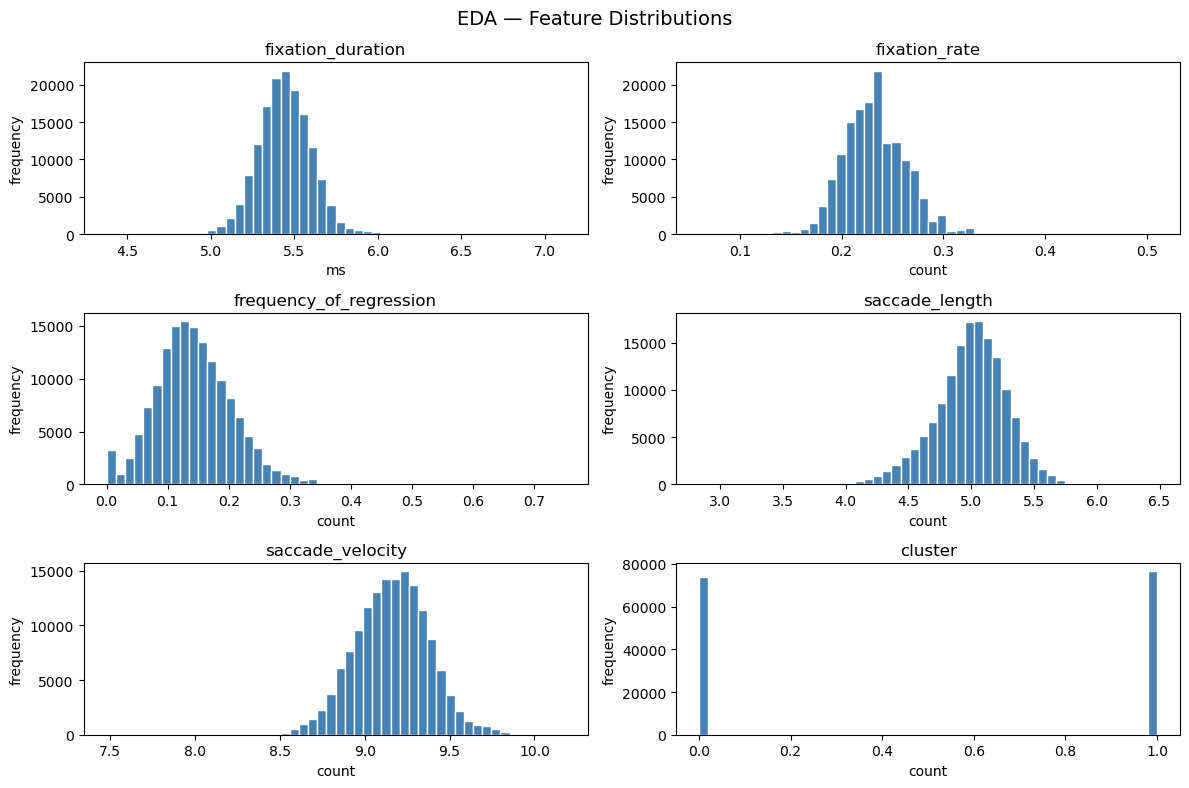

In [331]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
fig.suptitle("EDA — Feature Distributions", fontsize=14)

for ax, col in zip(axes.flat, features.columns):
    ax.hist(features[col], bins=50, edgecolor="white", color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("ms" if "dur" in col else "count")
    ax.set_ylabel("frequency")

plt.tight_layout()
plt.show()

In [332]:
inertia = []
for n in range(1, 15):
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

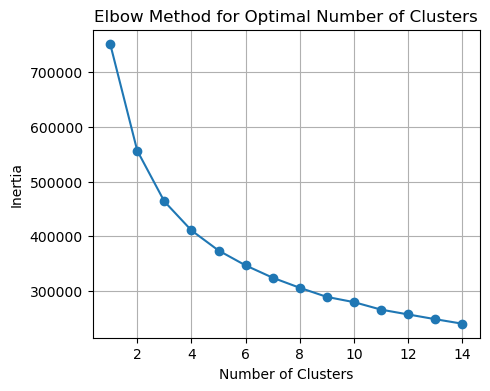

In [333]:
plt.figure(figsize=(5, 4))
plt.plot(range(1, 15), inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [ ]:
https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

For n_clusters = 2 The average silhouette_score is : 0.951847569924004
For n_clusters = 3 The average silhouette_score is : 0.3439821782761901
For n_clusters = 4 The average silhouette_score is : 0.2714595698283006


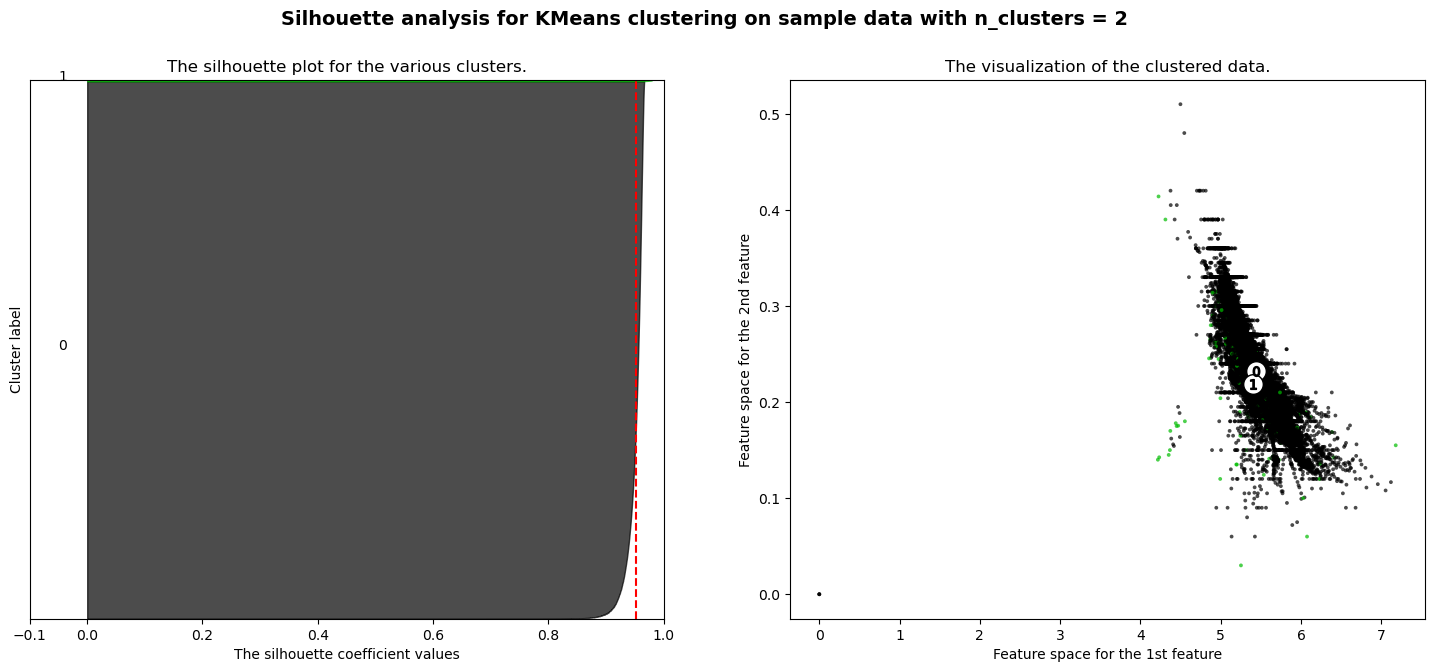

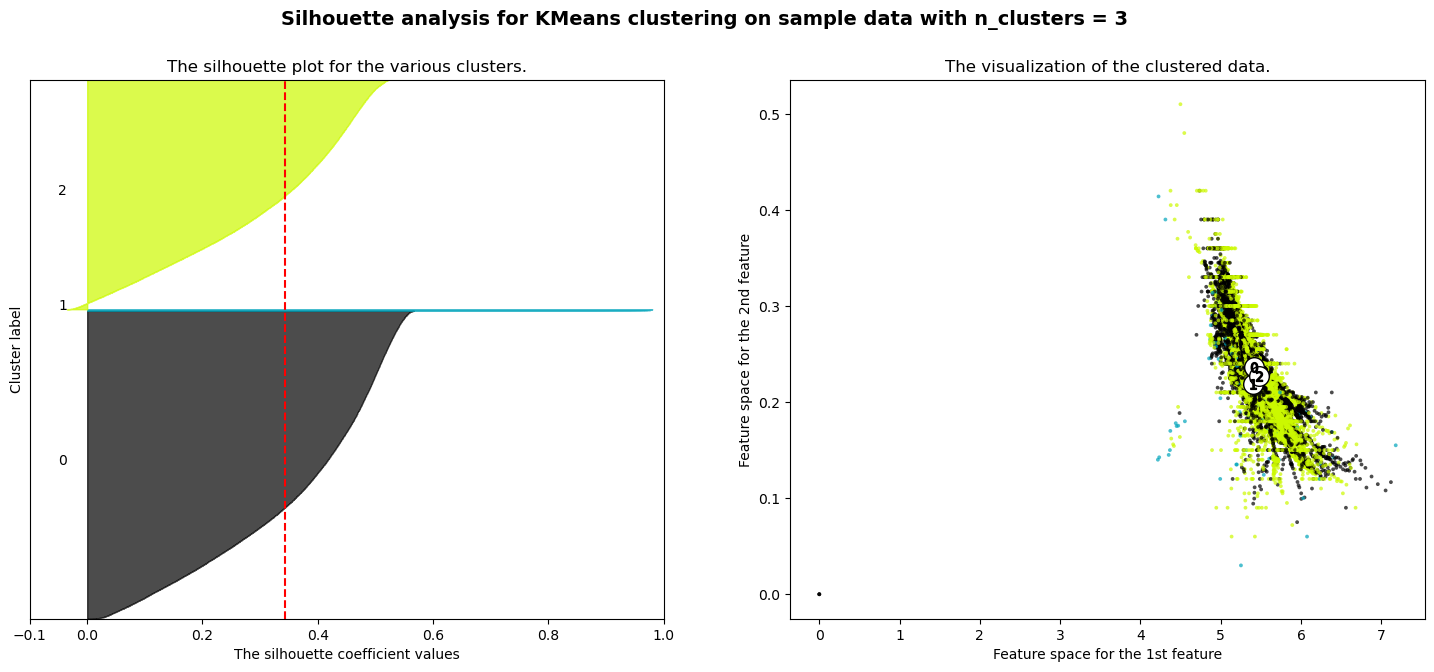

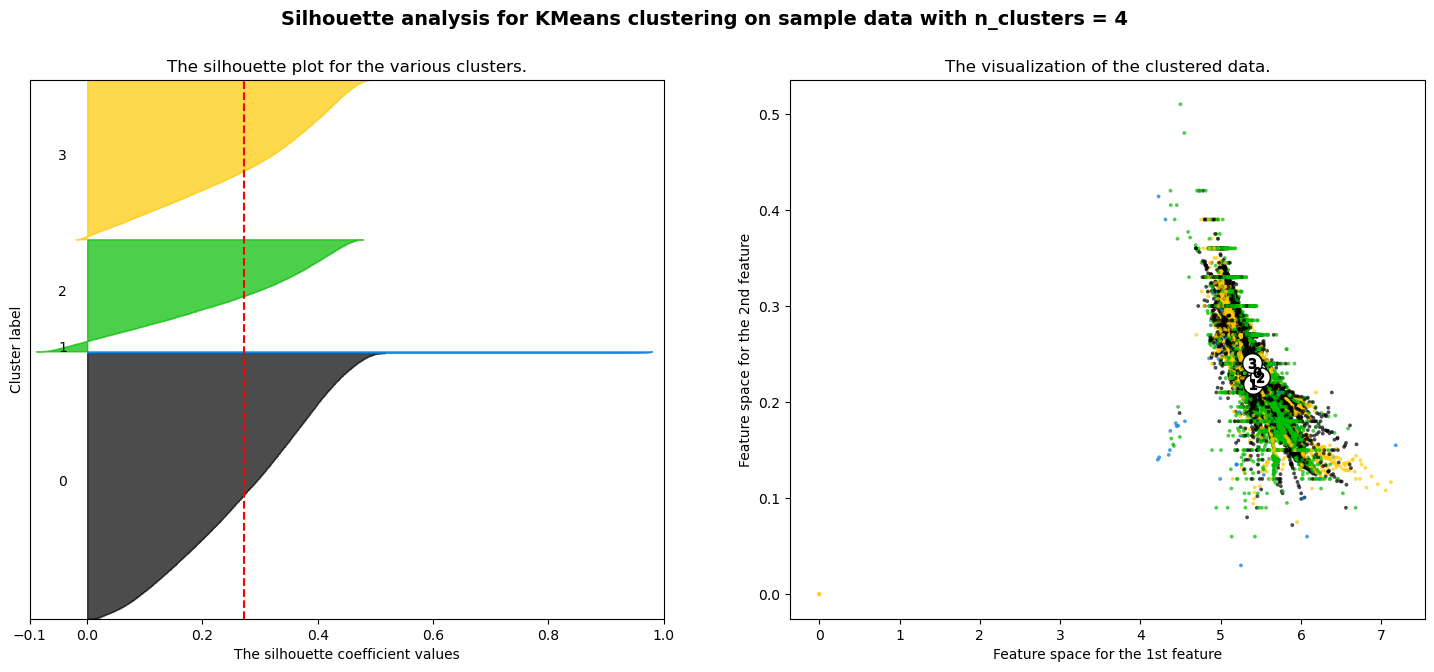

In [ ]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
range_n_clusters = [2, 3, 4]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

For n_clusters = 2 The average silhouette_score is : 0.27121657850359054
For n_clusters = 3 The average silhouette_score is : 0.2228008592593163
For n_clusters = 4 The average silhouette_score is : 0.24032431145787816
For n_clusters = 5 The average silhouette_score is : 0.22340912684461492


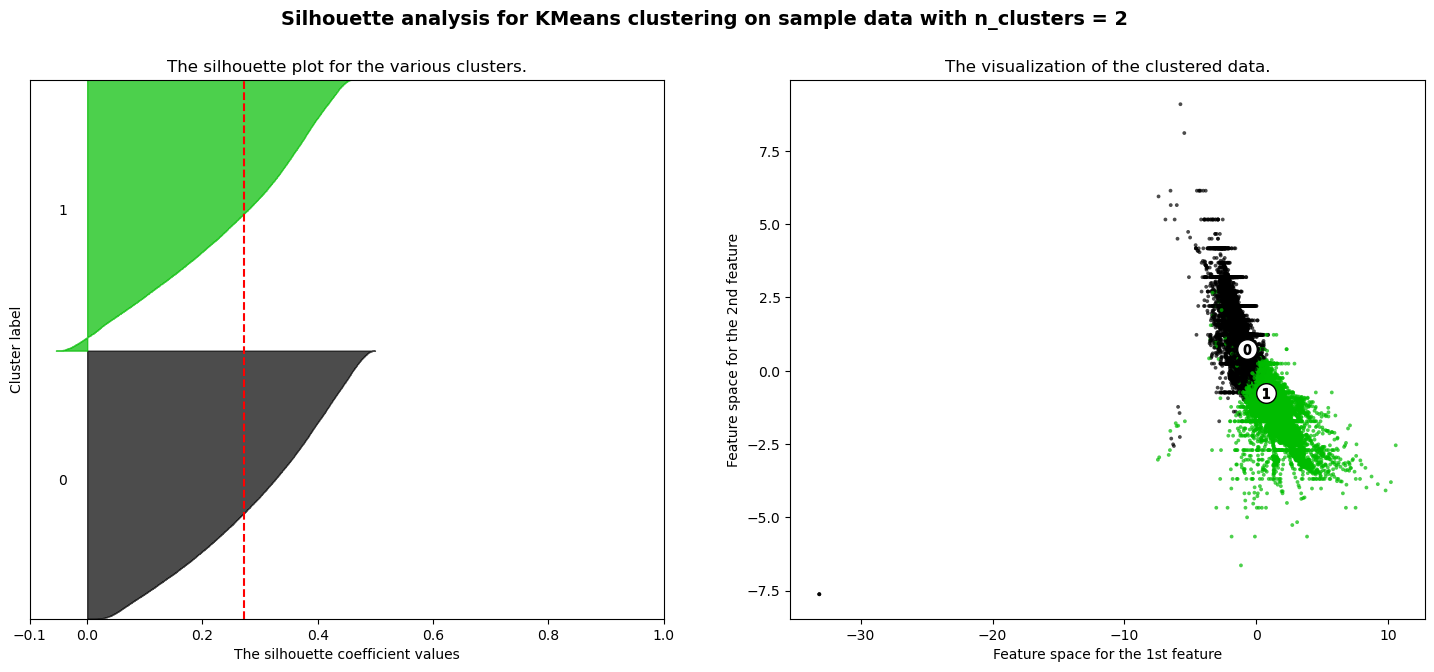

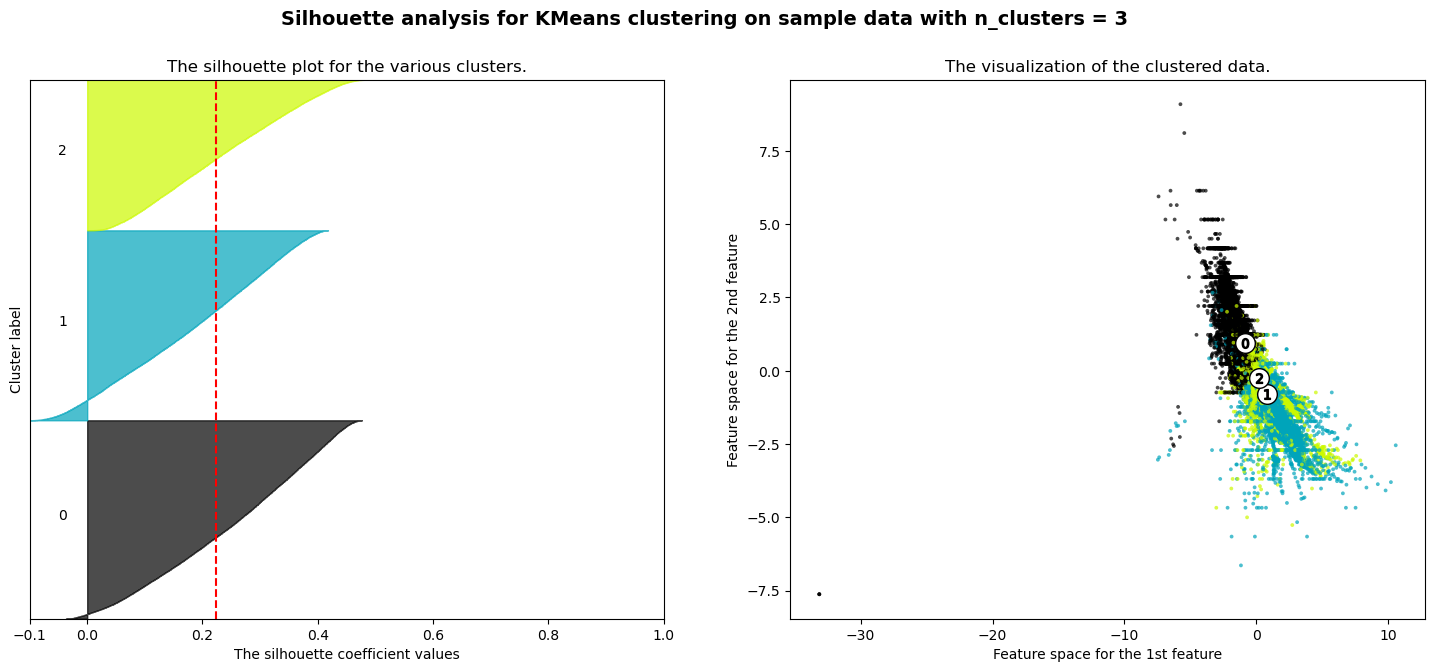

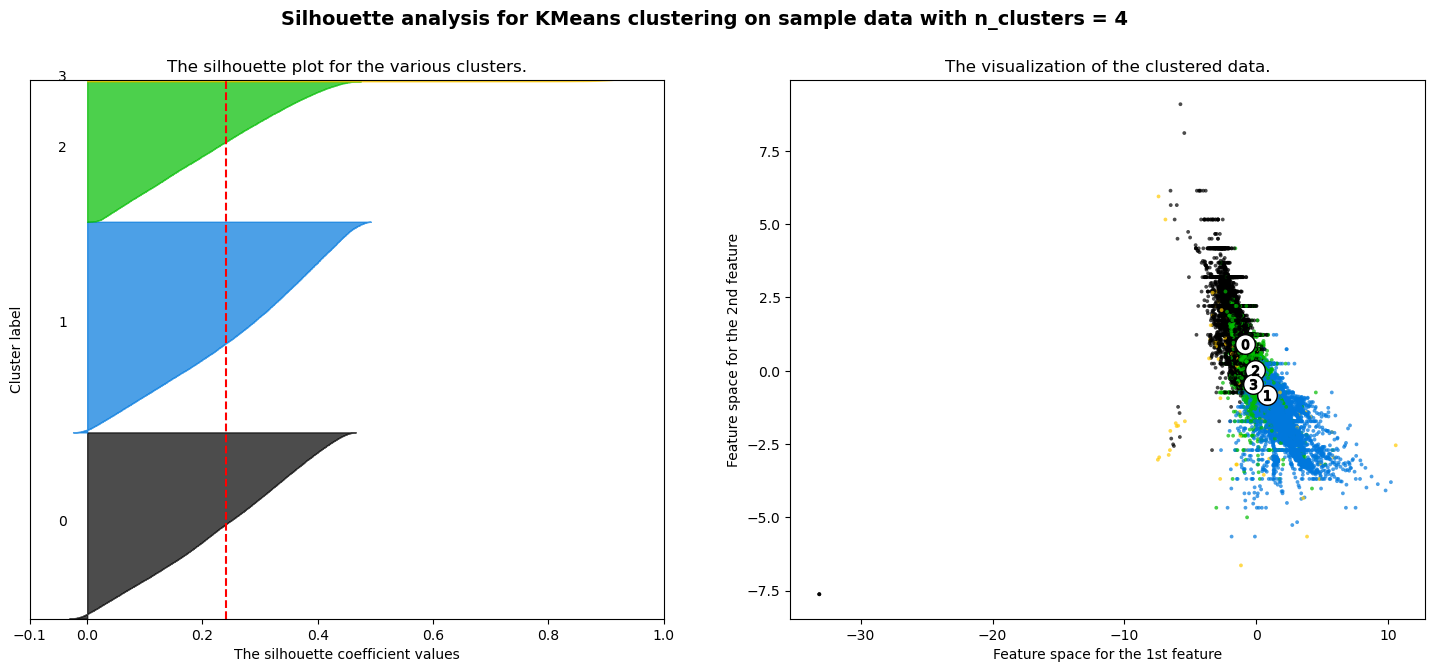

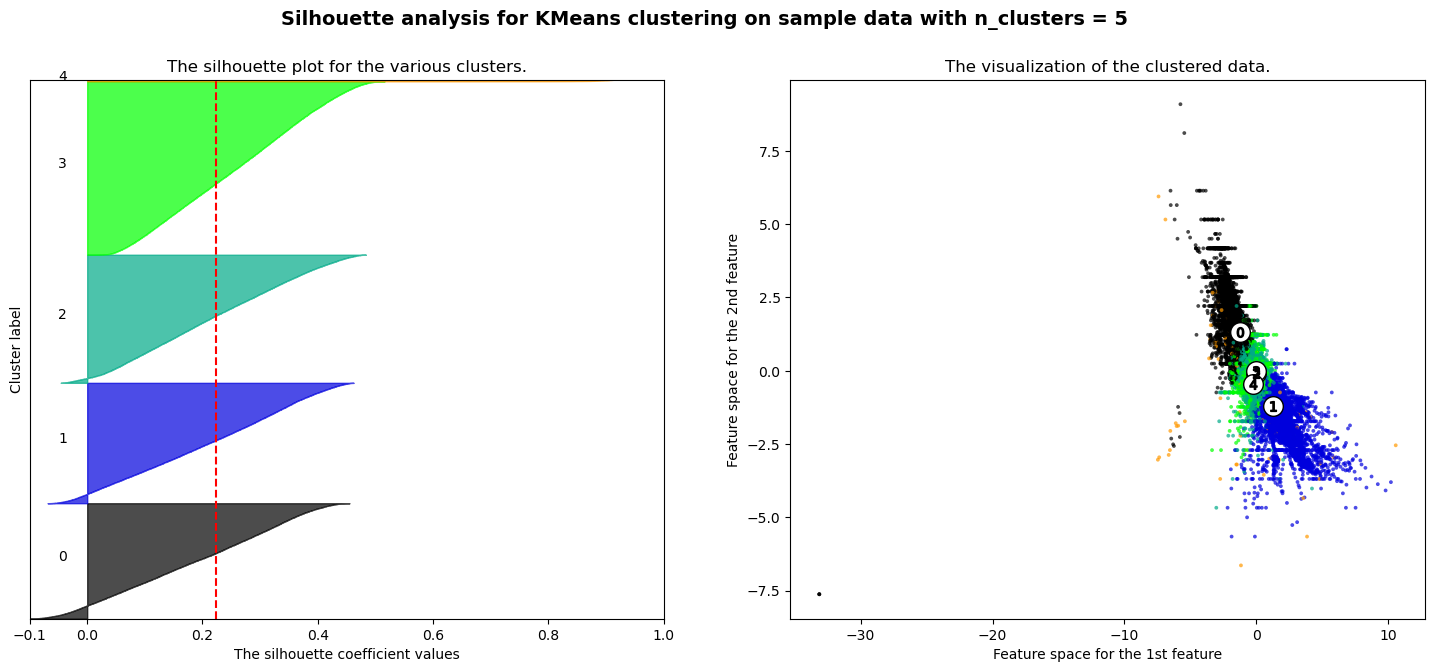

In [318]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
range_n_clusters = [2, 3, 4, 5]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X_scaled)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X_scaled[:, 0], X_scaled[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

For n_clusters = 2 The average silhouette_score is : 0.23566825854649637
For n_clusters = 3 The average silhouette_score is : 0.20159499411879597
For n_clusters = 4 The average silhouette_score is : 0.19553283554646533
For n_clusters = 5 The average silhouette_score is : 0.18455172650970272


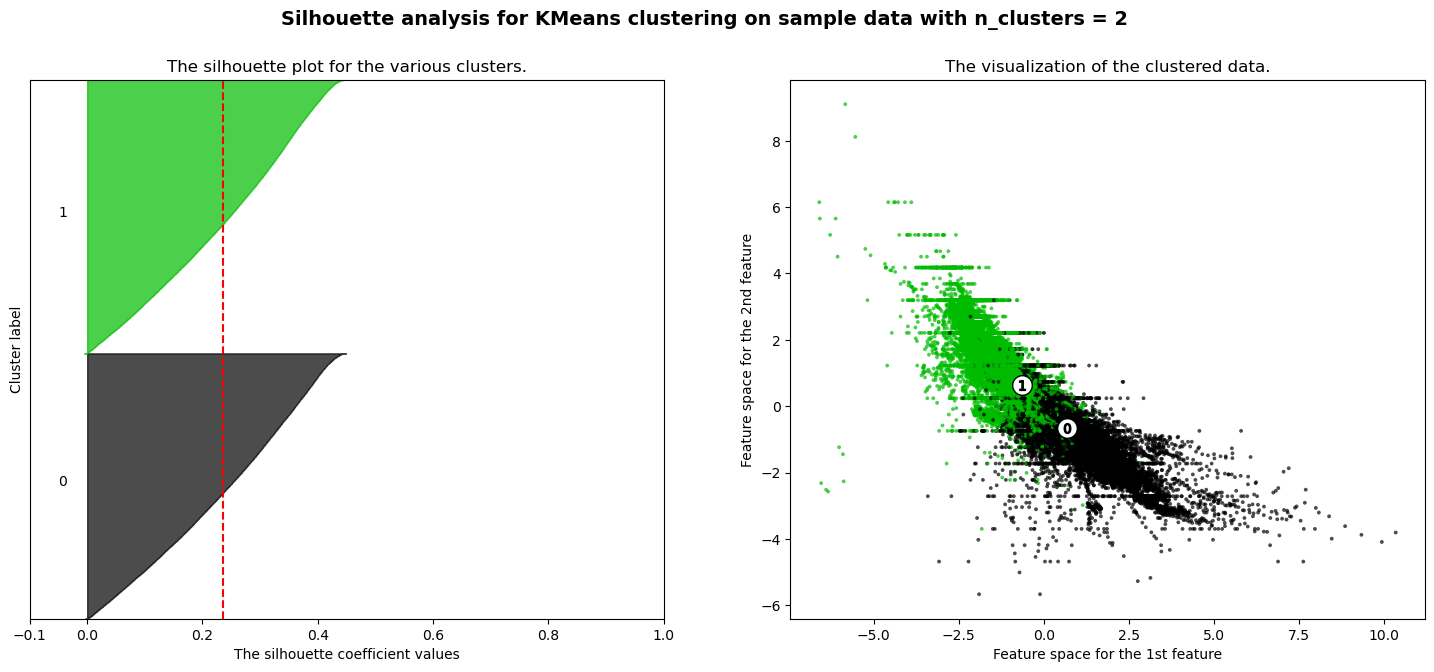

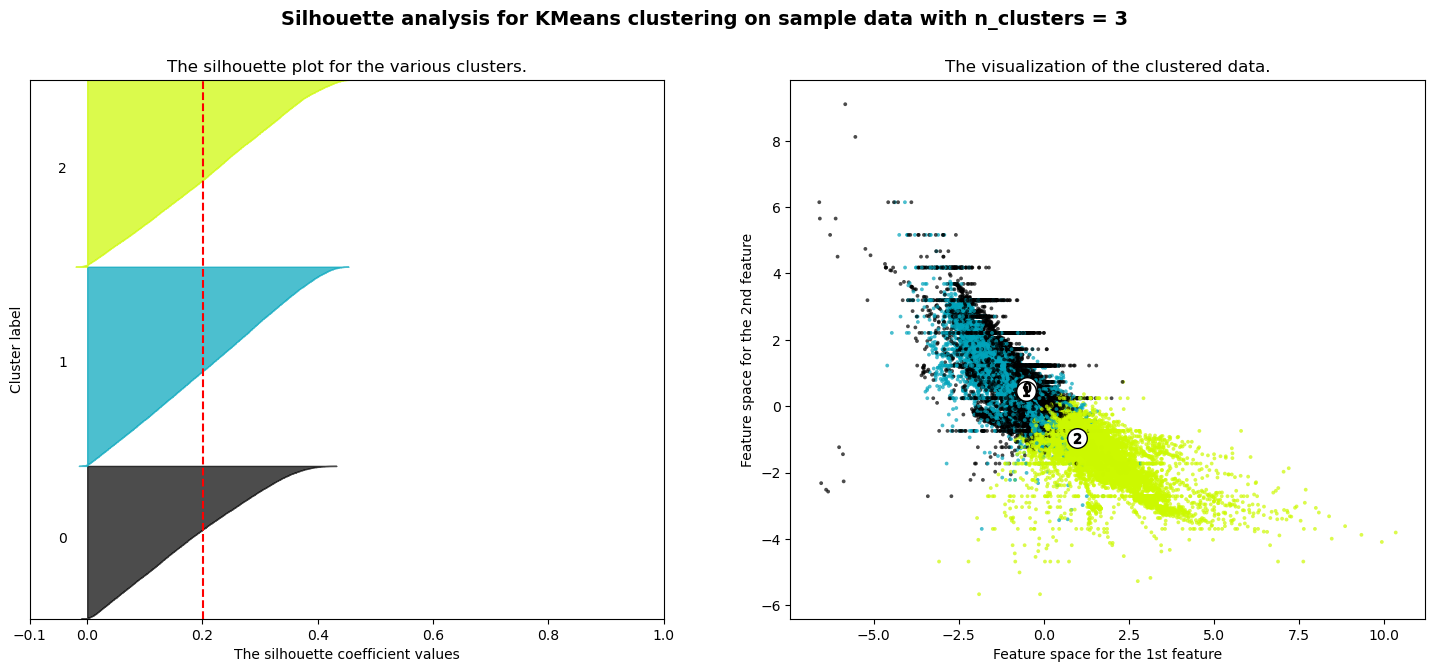

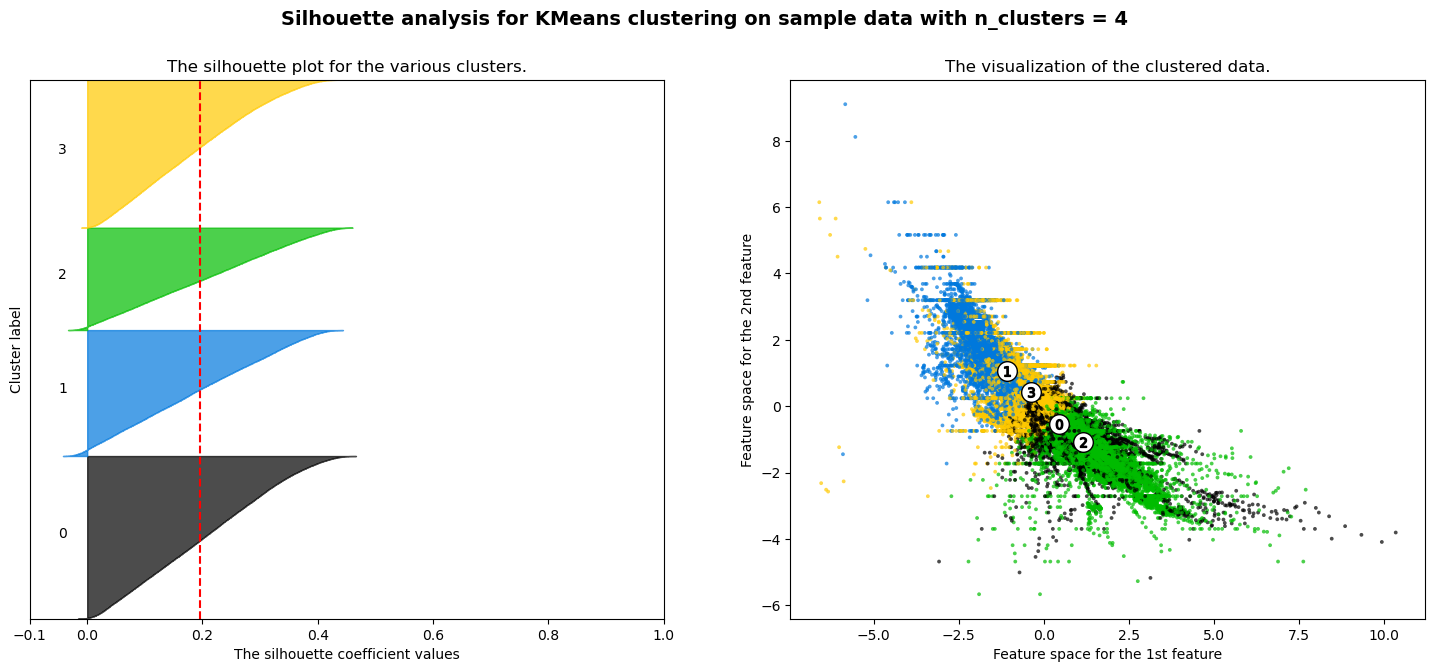

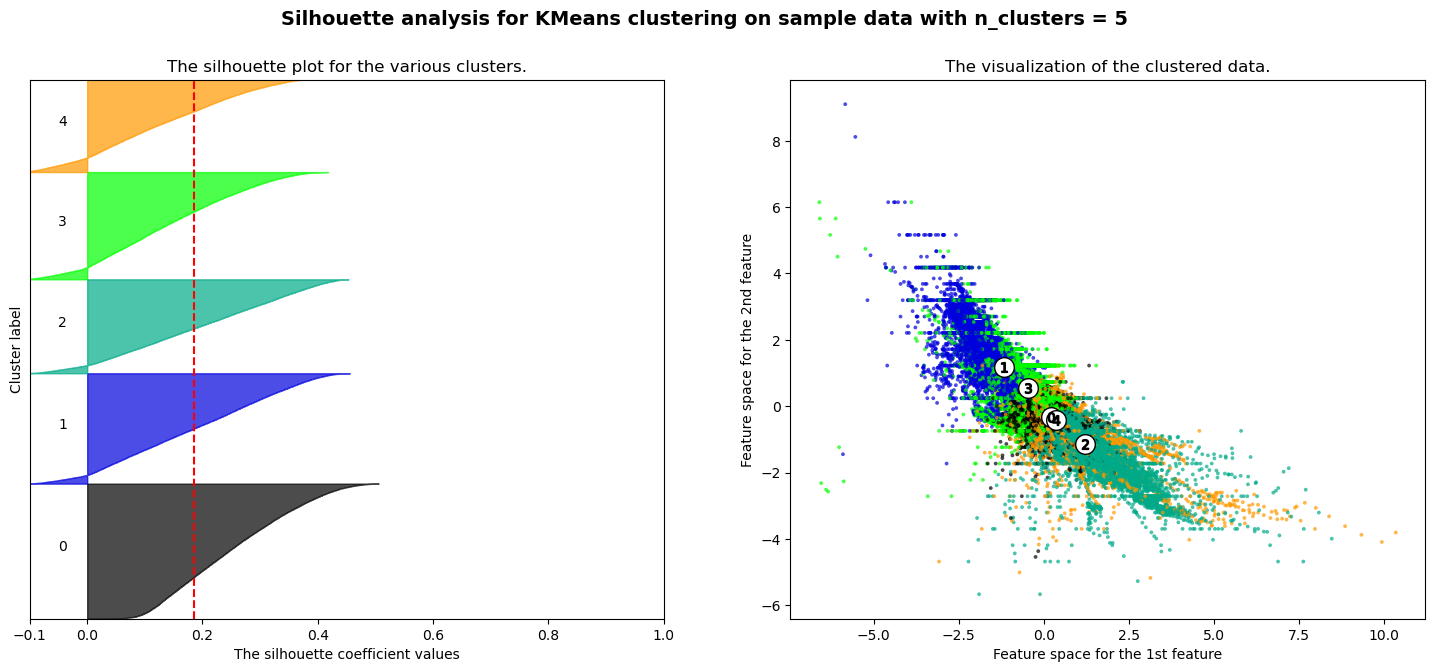

In [334]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
range_n_clusters = [2, 3, 4, 5]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X_scaled)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X_scaled[:, 0], X_scaled[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()